# Leave-KGC-Models-Out: Fully Automated Evaluation Loop
**REVISED v2 - With All 3 Changes Implemented**

## KEY REVISIONS:
1. **Consistency & Generalizability**: Normalized using `value/max` formula (max=1, min≠0)
2. **Aggregated Changes**: Final summed changes normalized column-wise (max per column = 1)
3. **Multiple Plots**: 7 different visualization styles (bar, box, std bar, violin, heatmap, combined)

No-Free-Lunch Principle in Metric Aggregation for Knowledge Graph Completion

## Step 0A: Mount Google Drive & Install Dependencies

In [ ]:

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Step 1: Load Original Dataset

In [ ]:
import pandas as pd
import numpy as np
import os
import itertools
import warnings
import time
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

ORIGINAL_DATA_PATH = '/content/drive/MyDrive/No_Free_Lunch_KGC/Tail_pred_main_file.csv'
DATA_DIR = os.path.dirname(ORIGINAL_DATA_PATH)
RESULTS_OUTPUT_DIR = os.path.join(DATA_DIR, 'No_Free_Lunch_Results')
os.makedirs(RESULTS_OUTPUT_DIR, exist_ok=True)

def load_file(path):
    """Load CSV with multiple fallback separators."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    for sep in [',', '\t', ' ']:
        try:
            return pd.read_csv(path, sep=sep)
        except Exception:
            continue
    raise ValueError(f"Could not parse {path} as CSV.")

FULL_DF = load_file(ORIGINAL_DATA_PATH)
ALL_MODELS = sorted(FULL_DF['Models'].unique().tolist())
ALL_PAIRS = list(itertools.combinations(ALL_MODELS, 2))

print(f"✓ Dataset loaded: {FULL_DF.shape[0]} rows × {FULL_DF.shape[1]} columns")
print(f"✓ Unique KGC models detected ({len(ALL_MODELS)}):")
for m in ALL_MODELS:
    print(f"   • {m}")
print(f"\n✓ Total model pairs to evaluate: {len(ALL_PAIRS)}")
print(f"✓ Results will be saved to: {RESULTS_OUTPUT_DIR}/")

✓ Dataset loaded: 20 rows × 21 columns
✓ Unique KGC models detected (20):
   • ANALOGY
   • CompGCN
   • ComplEx
   • ConvE
   • ConvKB
   • ConvR
   • CrossE
   • DistMult
   • DualE
   • HakE
   • HolE
   • NodePiece
   • R-GCN
   • RSN
   • RotatE
   • STransE
   • SimplE
   • TorusE
   • TransE
   • TuckER

✓ Total model pairs to evaluate: 190
✓ Results will be saved to: /content/drive/MyDrive/No_Free_Lunch_KGC/No_Free_Lunch_Results/


In [ ]:
FULL_DF

,Models,MR_d0,MRR_d0,H@1_d0,H@10_d0,MR_d1,MRR_d1,H@1_d1,H@10_d1,MR_d2,...,H@1_d2,H@10_d2,MR_d3,MRR_d3,H@1_d3,H@10_d3,MR_d4,MRR_d4,H@1_d4,H@10_d4
0,TransE,45,0.628,0.494,0.847,279,0.646,0.406,0.949,209,...,0.217,0.497,3936,0.206,0.028,0.495,1187,0.501,0.406,0.674
1,STransE,69,0.543,0.398,0.796,208,0.656,0.431,0.935,357,...,0.225,0.496,5172,0.226,0.101,0.422,5797,0.049,0.033,0.074
2,CrossE,136,0.702,0.601,0.862,441,0.834,0.733,0.950,227,...,0.212,0.471,5212,0.405,0.381,0.450,3839,0.446,0.331,0.654
3,TorusE,143,0.746,0.689,0.840,525,0.947,0.943,0.954,211,...,0.196,0.447,4873,0.463,0.427,0.534,1945,0.342,0.274,0.474
4,RotatE,42,0.791,0.739,0.881,274,0.949,0.943,0.960,178,...,0.238,0.531,3318,0.475,0.426,0.573,1827,0.498,0.405,0.671
5,HakE,128,0.714,0.639,0.834,304,0.934,0.919,0.957,160,...,0.250,0.542,2250,0.497,0.452,0.582,1130,0.545,0.462,0.694
6,DualE,21,0.813,0.766,0.896,156,0.952,0.946,0.962,91,...,0.268,0.559,2270,0.492,0.444,0.584,2068,0.280,0.096,0.591
7,DistMult,173,0.784,0.736,0.863,675,0.824,0.726,0.946,199,...,0.224,0.490,5913,0.433,0.397,0.502,1107,0.501,0.413,0.661
8,ComplEx,34,0.848,0.816,0.905,3623,0.949,0.945,0.955,202,...,0.257,0.530,4907,0.458,0.426,0.521,1112,0.576,0.505,0.704
9,ANALOGY,126,0.726,0.656,0.837,808,0.934,0.926,0.944,476,...,0.126,0.354,9266,0.366,0.358,0.380,2423,0.283,0.192,0.457


## Step 2A: Core MCDM Functions

In [ ]:
from scipy.stats import zscore, kendalltau, pearsonr, spearmanr
from scipy import stats

'''

def normalize_for_mcdm(df, beneficial_cols, non_beneficial_cols):
    """Min-max normalize: beneficial → [0,1], non-beneficial → [0.6, 0.8]."""
    df_norm = df.copy()
    for col in beneficial_cols:
        if col not in df_norm.columns:
            continue
        cmin, cmax = df_norm[col].min(), df_norm[col].max()
        df_norm[col] = 1.0 if cmax == cmin else (df_norm[col] - cmin) / (cmax - cmin)
    for col in non_beneficial_cols:
        if col not in df_norm.columns:
            continue
        cmax = df_norm[col].max()
        df_norm[col] = 0.6 if cmax == 0 else 0.6 + (df_norm[col] / cmax) * 0.2
    return df_norm
'''


def normalize_for_mcdm(df, beneficial_cols, non_beneficial_cols):
    """Min-max normalize with protection against zero variance (common with BERT/GNN models)."""
    df_norm = df.copy()

    for col in beneficial_cols:
        if col not in df_norm.columns:
            continue
        cmin = df_norm[col].min()
        cmax = df_norm[col].max()
        if cmax == cmin:                    # All values are the same
            df_norm[col] = 1.0
        else:
            df_norm[col] = (df_norm[col] - cmin) / (cmax - cmin)

    for col in non_beneficial_cols:
        if col not in df_norm.columns:
            continue
        cmax = df_norm[col].max()
        if cmax == 0:
            df_norm[col] = 0.6
        else:
            df_norm[col] = 0.6 + (df_norm[col] / cmax) * 0.2

    return df_norm





def borda_count_local(df):
    m = df.shape[0]
    return (m - df.rank(ascending=False, method='average') + 1).sum(axis=1).round(4)

def zscore_average_local(df):
    return df.apply(zscore, axis=0, nan_policy='omit').fillna(0).mean(axis=1).round(4)

def topsis_local(df, weights=None):
    X = df.values.astype(float)
    m, n = X.shape
    w = np.ones(n) / n if weights is None else np.array(weights) / np.sum(weights)
    norm = np.sqrt(np.sum(X**2, axis=0)); norm[norm == 0] = 1.0
    V = (X / norm) * w
    d_best = np.sqrt(np.sum((V - V.max(axis=0))**2, axis=1))
    d_worst = np.sqrt(np.sum((V - V.min(axis=0))**2, axis=1))
    return pd.Series(d_worst / (d_best + d_worst + 1e-12), index=df.index).round(4)

def vikor_local(df, weights=None, v=0.5):
    X = df.values.astype(float)
    m, n = X.shape
    w = np.ones(n) / n if weights is None else np.asarray(weights) / np.sum(weights)
    f_star, f_minus = X.max(axis=0), X.min(axis=0)
    denom = f_star - f_minus; denom[denom == 0] = 1.0
    D = (f_star - X) / denom
    S, R = np.dot(D, w), np.max(w * D, axis=1)
    S_min, S_max = S.min(), S.max()
    R_min, R_max = R.min(), R.max()
    S_denom = max(S_max - S_min, 1e-12)
    R_denom = max(R_max - R_min, 1e-12)
    Q = v * (S - S_min) / S_denom + (1 - v) * (R - R_min) / R_denom
    return pd.Series(Q, index=df.index).round(4)

def edas_local(df, weights=None):
    X = df.values.astype(float)
    w = np.ones(X.shape[1]) / X.shape[1] if weights is None else np.asarray(weights) / np.sum(weights)
    av = X.mean(axis=0)
    PDA = np.sum((X >= av).astype(float) * ((X - av) / (av + 1e-12)) * w, axis=1)
    NDA = np.sum((X < av).astype(float) * ((av - X) / (av + 1e-12)) * w, axis=1)
    return pd.Series((PDA + NDA) / 2, index=df.index).round(4)

def moora_local(df, weights=None):
    X = df.values.astype(float)
    w = np.ones(X.shape[1]) / X.shape[1] if weights is None else np.asarray(weights) / np.sum(weights)
    sq_sum = np.sqrt((X**2).sum(axis=0)); sq_sum[sq_sum == 0] = 1.0
    return pd.Series(((X / sq_sum) * w).sum(axis=1), index=df.index).round(4)

def waspas_local(df, weights=None, lam=0.5):
    X = df.values.astype(float)
    w = np.ones(X.shape[1]) / X.shape[1] if weights is None else np.asarray(weights) / np.sum(weights)
    sq_sum = np.sqrt((X**2).sum(axis=0)); sq_sum[sq_sum == 0] = 1.0
    X_norm = X / sq_sum
    WSM = (X_norm * w).sum(axis=1)
    prod = np.prod(X_norm ** w, axis=1)
    return pd.Series(lam * WSM + (1 - lam) * prod, index=df.index).round(4)

print("✓ MCDM functions defined")

✓ MCDM functions defined


## Step 2B: Evaluation Pipeline - With REVISED Consistency & Generalizability

In [ ]:
MCDM_KEYS = ['Borda', 'ZMean', 'TOPSIS', 'VIKOR', 'EDAS', 'MOORA', 'WASPAS']



'''
def _run_mcdm(df_filtered):
    r = pd.DataFrame(index=df_filtered.index)
    r['Borda'] = borda_count_local(df_filtered)
    r['ZMean'] = zscore_average_local(df_filtered)
    r['TOPSIS'] = topsis_local(df_filtered)
    r['VIKOR'] = vikor_local(df_filtered)
    r['EDAS'] = edas_local(df_filtered)
    r['MOORA'] = moora_local(df_filtered)
    r['WASPAS'] = waspas_local(df_filtered)
    for col in MCDM_KEYS:
        asc = col == 'VIKOR'
        r[f'{col}_R'] = r[col].rank(ascending=asc, method='min').astype(int)
    return r
'''


def _run_mcdm(df_filtered):
    """Robust MCDM that safely handles NaN/inf caused by mixed-scale models."""
    r = pd.DataFrame(index=df_filtered.index)

    r['Borda'] = borda_count_local(df_filtered)
    r['ZMean'] = zscore_average_local(df_filtered)
    r['TOPSIS'] = topsis_local(df_filtered)
    r['VIKOR'] = vikor_local(df_filtered)
    r['EDAS'] = edas_local(df_filtered)
    r['MOORA'] = moora_local(df_filtered)
    r['WASPAS'] = waspas_local(df_filtered)

    for col in MCDM_KEYS:
        asc = col == 'VIKOR'
        ranked = r[col].rank(ascending=asc, method='min')

        # Safe handling of NaN/inf → assign worst possible rank
        max_rank = len(df_filtered) + 1
        r[f'{col}_R'] = ranked.fillna(max_rank).astype(int)

    return r

# ── REVISED: Consistency with value/max normalization ──
def _run_consistency(df_metrics, df_normalized):
    """Returns Consistency with value/max normalization (max=1, min≠0)."""
    mrr_cols = [c for c in df_metrics.columns if 'MRR' in c]
    hit1_cols = [c for c in df_metrics.columns if 'H@1' in c and 'H@10' not in c]
    hit10_cols = [c for c in df_metrics.columns if 'H@10' in c]
    mr_cols = [c for c in df_metrics.columns if c.startswith('MR') and 'MRR' not in c]

    b_cols = [c for c in df_metrics.columns if c.startswith(('MRR','H@1','H@10'))]
    nb_cols = [c for c in df_metrics.columns if c.startswith('MR') and 'MRR' not in c]
    df_norm = normalize_for_mcdm(df_metrics, b_cols, nb_cols)

    results = pd.DataFrame(index=df_metrics.index)
    results['EDAS_AS'] = edas_local(df_norm)
    results['TOPSIS'] = topsis_local(df_norm)
    results['VIKOR_Q'] = vikor_local(df_norm)
    results['Borda_Score'] = borda_count_local(df_norm)
    results['Z_Mean'] = zscore_average_local(df_norm)
    results['MOORA'] = moora_local(df_norm)
    results['WASPAS'] = waspas_local(df_norm)

    mean_mrr = df_metrics[mrr_cols].mean(axis=1) if mrr_cols else pd.Series(0, index=df_metrics.index)
    mean_hit1 = df_metrics[hit1_cols].mean(axis=1) if hit1_cols else pd.Series(0, index=df_metrics.index)
    mean_hit10 = df_metrics[hit10_cols].mean(axis=1) if hit10_cols else pd.Series(0, index=df_metrics.index)
    mean_mr_inv = -df_metrics[mr_cols].mean(axis=1) if mr_cols else pd.Series(0, index=df_metrics.index)

    results['Mean_MRR'] = mean_mrr
    results['Mean_Hit@1'] = mean_hit1
    results['Mean_Hit@10'] = mean_hit10
    results['Mean_MR_inverted'] = mean_mr_inv

    mcdm_score_columns = {
        'EDAS': 'EDAS_AS', 'TOPSIS': 'TOPSIS', 'VIKOR': 'VIKOR_Q',
        'Borda': 'Borda_Score', 'Z-Score': 'Z_Mean', 'MOORA': 'MOORA', 'WASPAS': 'WASPAS'
    }
    consensus_metrics = {
        'Mean_MRR': 'Mean_MRR', 'Mean_Hit@1': 'Mean_Hit@1',
        'Mean_Hit@10': 'Mean_Hit@10', 'Mean_MR': 'Mean_MR_inverted'
    }

    all_corr = []
    for mn, mc in consensus_metrics.items():
        metric_data = results[mc]
        for mname, scol in mcdm_score_columns.items():
            md = -results[scol] if mname == 'VIKOR' else results[scol].copy()
            try:
                tau, _ = kendalltau(md, metric_data)
                r, _ = pearsonr(md, metric_data)
                rho, _ = spearmanr(md, metric_data)
            except Exception:
                tau = r = rho = np.nan
            all_corr.append({'Method': mname, 'Kendall_t': tau, 'Pearson_r': r, 'Spearman_rho': rho})

    summary = pd.DataFrame(all_corr)
    overall = []
    for method in mcdm_score_columns.keys():
        md = summary[summary['Method'] == method]
        mk = md['Kendall_t'].mean()
        mp = md['Pearson_r'].mean()
        ms = md['Spearman_rho'].mean()
        overall.append({'Method': method, 'Overall_Mean_Correlation': (mk + mp + ms) / 3})

    result_df = pd.DataFrame(overall)
    # REVISED: Normalize using value/max (max=1, min≠0)
    max_val = result_df['Overall_Mean_Correlation'].max()
    if max_val > 0:
        result_df['Overall_Mean_Correlation'] = (result_df['Overall_Mean_Correlation'] / max_val).round(4)
    return result_df

def _run_stability(df_metrics):
    """Returns normalized stability score per method (higher = more stable)."""
    datasets = []
    for col in df_metrics.columns:
        if '_' in col:
            ds = col.split('_')[-1]
            if ds not in datasets:
                datasets.append(ds)
    datasets = sorted(datasets)

    dataset_columns = {}
    for ds in datasets:
        dataset_columns[ds] = [c for c in df_metrics.columns if c.endswith(f'_{ds}')]

    metric_types = ['MR', 'MRR', 'H@1', 'H@10']
    name_map = {'VQ': 'VIKOR Q', 'BS': 'Borda', 'ZS': 'Z-Score', 'WA': 'WASPAS', 'MO': 'MOORA', 'ED': 'EDAS', 'TP': 'TOPSIS'}

    all_ranks = {}
    for metric_type in metric_types:
        mc_by_ds = {}
        for ds in datasets:
            mc = [c for c in dataset_columns[ds] if c.startswith(metric_type)]
            if mc:
                mc_by_ds[ds] = mc
        if not mc_by_ds:
            continue
        ds_ranks = {}
        for ds, metric_cols in mc_by_ds.items():
            df_m = df_metrics[metric_cols].copy()
            b = [] if metric_type == 'MR' else metric_cols
            nb = metric_cols if metric_type == 'MR' else []
            df_n = normalize_for_mcdm(df_m, b, nb)
            res_ds = pd.DataFrame(index=df_metrics.index)
            res_ds['ED_Rank'] = edas_local(df_n).rank(ascending=False, method='min').astype(int)
            res_ds['TP_Rank'] = topsis_local(df_n).rank(ascending=False, method='min').astype(int)
            res_ds['VQ_Rank'] = vikor_local(df_n).rank(ascending=True, method='min').astype(int)
            res_ds['BS_Rank'] = borda_count_local(df_n).rank(ascending=False, method='min').astype(int)
            res_ds['ZS_Rank'] = zscore_average_local(df_n).rank(ascending=False, method='min').astype(int)
            res_ds['MO_Rank'] = moora_local(df_n).rank(ascending=False, method='min').astype(int)
            res_ds['WA_Rank'] = waspas_local(df_n).rank(ascending=False, method='min').astype(int)
            ds_ranks[ds] = res_ds[['ED_Rank', 'TP_Rank', 'VQ_Rank', 'BS_Rank', 'ZS_Rank', 'MO_Rank', 'WA_Rank']].copy()
        all_ranks[metric_type] = ds_ranks

    overall_var = pd.DataFrame(index=df_metrics.index)
    for short, full in name_map.items():
        all_mv = []
        for mt, ds_ranks in all_ranks.items():
            for ds, rdf in ds_ranks.items():
                col = f'{short}_Rank'
                if col in rdf.columns:
                    all_mv.append(rdf[col])
        if all_mv:
            stacked = pd.concat(all_mv, axis=1)
            overall_var[full] = stacked.var(axis=1, ddof=0).round(3)

    if overall_var.empty:
        return {m: 0.5 for m in ['Borda', 'Z-Score', 'TOPSIS', 'VIKOR', 'EDAS', 'MOORA', 'WASPAS']}

    raw_mean = overall_var.mean()
    inv = 1 / raw_mean.replace(0, np.inf)
    max_inv = inv.max()
    if max_inv == 0 or np.isinf(max_inv):
        norm = {k: 0.0 for k in raw_mean.index}
    else:
        norm_series = (inv / max_inv).replace([np.inf, -np.inf], 0).fillna(0).round(4)
        norm = norm_series.to_dict()

    mapping = {'VIKOR Q': 'VIKOR', 'Z-Score': 'Z-Score', 'Borda': 'Borda', 'WASPAS': 'WASPAS', 'MOORA': 'MOORA', 'EDAS': 'EDAS', 'TOPSIS': 'TOPSIS'}
    return {mapping.get(k, k): v for k, v in norm.items()}

def _run_independency(df_metrics):
    """Leave-one-metric-family-out robustness."""
    all_cols = df_metrics.columns.tolist()
    metric_families = {'MR': [], 'MRR': [], 'H@1': [], 'H@10': []}
    for col in all_cols:
        if col.startswith('MR_') and not col.startswith('MRR_'):
            metric_families['MR'].append(col)
        elif col.startswith('MRR_'):
            metric_families['MRR'].append(col)
        elif col.startswith('H@1_'):
            metric_families['H@1'].append(col)
        elif col.startswith('H@10_'):
            metric_families['H@10'].append(col)

    baseline = _run_mcdm(df_metrics)
    def avg_delta(base, new_res):
        return {m: (base[f'{m}_R'] - new_res[f'{m}_R']).abs().mean() for m in MCDM_KEYS}

    robustness_scores = {m: 0.0 for m in MCDM_KEYS}
    for fam, excl in metric_families.items():
        remaining = [c for c in all_cols if c not in excl]
        if not remaining:
            continue
        new_res = _run_mcdm(df_metrics[remaining])
        for m, delta in avg_delta(baseline, new_res).items():
            robustness_scores[m] += delta
    for m in robustness_scores:
        robustness_scores[m] /= max(len(metric_families), 1)

    raw = pd.Series(robustness_scores)
    inv = 1 / raw.replace(0, np.inf)
    max_inv = inv.max()
    if max_inv == 0 or np.isinf(max_inv):
        norm = {m: 0.0 for m in MCDM_KEYS}
    else:
        norm_s = (inv / max_inv).replace([np.inf, -np.inf], 0).fillna(0).round(4)
        norm = norm_s.to_dict()

    mapping = {'ZMean': 'Z-Score'}
    return {mapping.get(k, k): v for k, v in norm.items()}

def _run_robustness(df_metrics, n_iter=1000):
    """Noise injection robustness."""
    baseline = _run_mcdm(df_metrics)
    noise_levels = [0.05, 0.10, 0.15, 0.20]
    agg_deltas = {m: 0.0 for m in MCDM_KEYS}

    for noise in noise_levels:
        noise_deltas = {m: 0.0 for m in MCDM_KEYS}
        for _ in range(n_iter):
            df_noisy = df_metrics.copy()
            for col in df_noisy.columns:
                std = df_noisy[col].std()
                df_noisy[col] += np.random.normal(0, noise * std, size=len(df_noisy))
            new_res = _run_mcdm(df_noisy)
            for m in MCDM_KEYS:
                noise_deltas[m] += (baseline[f'{m}_R'] - new_res[f'{m}_R']).abs().mean()
        for m in MCDM_KEYS:
            agg_deltas[m] += noise_deltas[m] / n_iter

    for m in MCDM_KEYS:
        agg_deltas[m] /= len(noise_levels)

    raw = pd.Series(agg_deltas)
    inv = 1 / raw.replace(0, np.inf)
    max_inv = inv.max()
    if max_inv == 0 or np.isinf(max_inv):
        norm = {m: 0.0 for m in MCDM_KEYS}
    else:
        norm_s = (inv / max_inv).replace([np.inf, -np.inf], 0).fillna(0).round(4)
        norm = norm_s.to_dict()

    mapping = {'ZMean': 'Z-Score'}
    return {mapping.get(k, k): v for k, v in norm.items()}

# ── REVISED: Generalizability with value/max normalization ──
def _run_generalizability(df_metrics):
    """Leave-dataset-out generalizability with value/max normalization (max=1, min≠0)."""
    datasets = []
    for col in df_metrics.columns:
        if '_' in col:
            ds = col.split('_')[-1]
            if ds not in datasets:
                datasets.append(ds)

    baseline = _run_mcdm(df_metrics)
    agg_deltas = {m: 0.0 for m in MCDM_KEYS}

    for ds in datasets:
        keep_cols = [c for c in df_metrics.columns if not c.endswith(f'_{ds}')]
        if not keep_cols:
            continue
        new_res = _run_mcdm(df_metrics[keep_cols])
        for m in MCDM_KEYS:
            agg_deltas[m] += (baseline[f'{m}_R'] - new_res[f'{m}_R']).abs().mean()

    for m in MCDM_KEYS:
        agg_deltas[m] /= max(len(datasets), 1)

    raw = pd.Series(agg_deltas)
    inv = 1 / raw.replace(0, np.inf)
    max_inv = inv.max()
    if max_inv == 0 or np.isinf(max_inv):
        norm = {m: 0.0 for m in MCDM_KEYS}
    else:
        norm_s = (inv / max_inv).replace([np.inf, -np.inf], 0).fillna(0).round(4)
        norm = norm_s.to_dict()

    result_df = pd.DataFrame(list(norm.items()), columns=['Method', 'Generalizability'])
    # REVISED: Normalize using value/max (max=1, min≠0)
    max_val = result_df['Generalizability'].max()
    if max_val > 0:
        result_df['Generalizability'] = (result_df['Generalizability'] / max_val).round(4)

    mapping = {'ZMean': 'Z-Score'}
    result_df['Method'] = result_df['Method'].map(mapping).fillna(result_df['Method'])
    return result_df

def run_full_pipeline(df, n_robustness_iter=1000):
    """Complete evaluation pipeline."""
    df_metrics = df.drop(columns=['Models']).copy()
    df_metrics.index = df['Models']

    b_cols = [c for c in df_metrics.columns if c.startswith(('MRR', 'H@1', 'H@10'))]
    nb_cols = [c for c in df_metrics.columns if c.startswith('MR') and 'MRR' not in c]
    df_norm = normalize_for_mcdm(df_metrics, b_cols, nb_cols)

    df_cons = _run_consistency(df_metrics, df_norm)
    df_cons = df_cons.rename(columns={'Overall_Mean_Correlation': 'Consistency'})

    stab_dict = _run_stability(df_metrics)
    df_stab = pd.DataFrame(list(stab_dict.items()), columns=['Method', 'Stability'])

    ind_dict = _run_independency(df_metrics)
    df_ind = pd.DataFrame(list(ind_dict.items()), columns=['Method', 'Independency'])

    rob_dict = _run_robustness(df_metrics, n_iter=n_robustness_iter)
    df_rob = pd.DataFrame(list(rob_dict.items()), columns=['Method', 'Robustness'])

    df_gen = _run_generalizability(df_metrics)

    summary = df_cons.merge(df_stab, on='Method').merge(df_ind, on='Method').merge(df_rob, on='Method').merge(df_gen, on='Method')
    summary['Overall Score'] = summary[['Consistency', 'Stability', 'Independency', 'Robustness', 'Generalizability']].mean(axis=1).round(4)
    summary = summary.sort_values(by='Overall Score', ascending=False).reset_index(drop=True)
    return summary

print("✓ Full evaluation pipeline defined (with REVISED functions)")

✓ Full evaluation pipeline defined (with REVISED functions)


## Step 3: Setup Constants and Directories

In [ ]:
BASE_DIR = os.path.join(RESULTS_OUTPUT_DIR, 'Base_Results')
ONE_DIR = os.path.join(RESULTS_OUTPUT_DIR, 'One_KGC_Removal')
TWO_DIR = os.path.join(RESULTS_OUTPUT_DIR, 'Two_KGC_Removal')
GROUP_DIR = os.path.join(RESULTS_OUTPUT_DIR, 'Group_KGC_Removal')
PLOT_DIR = os.path.join(RESULTS_OUTPUT_DIR, 'Plots')

for d in [BASE_DIR, ONE_DIR, TWO_DIR, GROUP_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

METRIC_COLS = ['Consistency', 'Stability', 'Independency', 'Robustness', 'Generalizability']
MCDM_ORDER = ['Z-Score', 'Borda', 'MOORA', 'EDAS', 'TOPSIS', 'WASPAS', 'VIKOR']
N_ROBUSTNESS_ITER = 100

# ===================================================================
# Updated KGC Groups - Matching the LaTeX table structure exactly
# ===================================================================
KGC_GROUPS = {
    'Translational / Geometric Models': [
        'TransE', 'STransE', 'CrossE', 'TorusE', 'RotatE',
        'HakE', 'DualE'
    ],

    'Semantic Matching Models': [
        'DistMult', 'ComplEx', 'ANALOGY', 'SimplE', 'HolE', 'TuckER'
    ],

    'Neural / CNN-based Models': [
        'ConvE', 'ConvKB', 'ConvR', 'RSN'
    ],

    'GNN-based Models': [
        'R-GCN', 'CompGCN', 'NodePiece'
    ]
}

def scores_to_ranks(score_df):
    """Convert scores to ranks (higher score = better rank)."""
    rank_df = score_df.copy().astype(float)
    for col in score_df.columns:
        rank_df[col] = score_df[col].rank(ascending=False, method='min').astype(int)
    return rank_df


print(f"✓ Setup complete - Output directory: {RESULTS_OUTPUT_DIR}")
print(f"✓ KGC Groups defined ({len(KGC_GROUPS)} groups):")
for group_name, models in KGC_GROUPS.items():
    print(f"   • {group_name}: {len(models)} models")

✓ Setup complete - Output directory: /content/drive/MyDrive/No_Free_Lunch_KGC/No_Free_Lunch_Results
✓ KGC Groups defined (4 groups):
   • Translational / Geometric Models: 7 models
   • Semantic Matching Models: 6 models
   • Neural / CNN-based Models: 4 models
   • GNN-based Models: 3 models


## Step 4: Compute Baseline

In [ ]:
base_scores_path = os.path.join(BASE_DIR, 'base_scores.csv')
base_ranks_path = os.path.join(BASE_DIR, 'base_ranks.csv')

if os.path.exists(base_scores_path):
    base_scores = pd.read_csv(base_scores_path, index_col=0)
    base_ranks = pd.read_csv(base_ranks_path, index_col=0)
    print('Loaded cached baseline scores.')
else:
    print('Computing baseline...')
    t0 = time.time()
    base_summary = run_full_pipeline(FULL_DF, n_robustness_iter=N_ROBUSTNESS_ITER)
    print(f'  Completed in {time.time() - t0:.1f}s')
    base_scores = base_summary.set_index('Method')[METRIC_COLS].reindex(MCDM_ORDER).round(4)
    base_ranks = scores_to_ranks(base_scores)
    base_summary.to_csv(os.path.join(BASE_DIR, 'base_summary.csv'))
    base_scores.to_csv(base_scores_path)
    base_ranks.to_csv(base_ranks_path)

print('\nBaseline Scores:')
print(base_scores)
print('\nBaseline Ranks:')
print(base_ranks)

Loaded cached baseline scores.

Baseline Scores:
         Consistency  Stability  Independency  Robustness  Generalizability
Method                                                                     
Z-Score       0.7001     1.0000        0.5333      1.0000            0.8571
Borda         0.6442     0.9763        1.0000      0.4950            1.0000
MOORA         0.7900     0.7848        0.2759      0.2822            0.4444
EDAS          0.8037     0.7682        0.3333      0.2895            0.8000
TOPSIS        0.7937     0.7794        0.3200      0.5844            0.7500
WASPAS        0.4214     0.8525        0.5000      0.2832            0.6667
VIKOR         0.4322     0.8391        0.5333      0.2375            0.7500

Baseline Ranks:
         Consistency  Stability  Independency  Robustness  Generalizability
Method                                                                     
Z-Score            4          1             2           1                 2
Borda              5  

## Step 5: One-KGC-Out Analysis

In [ ]:
RAW_ONE_DIR = os.path.join(ONE_DIR, 'raw')
os.makedirs(RAW_ONE_DIR, exist_ok=True)

print('=' * 70)
print('ONE-KGC-OUT ANALYSIS')
print(f'Total models: {len(ALL_MODELS)}')
print('=' * 70)

t0_loop = time.time()
one_abs_score_changes = []
one_abs_rank_changes = []

for m in ALL_MODELS:
    score_out = os.path.join(RAW_ONE_DIR, f'scores_without_{m}.csv')
    rank_out = os.path.join(RAW_ONE_DIR, f'ranks_without_{m}.csv')

    if os.path.exists(score_out) and os.path.exists(rank_out):
        res_scores = pd.read_csv(score_out, index_col=0)
        res_ranks = pd.read_csv(rank_out, index_col=0)
        print(f'  Loaded: {m}')
    else:
        t1 = time.time()
        print(f'  Removing: {m}', end=' ... ')
        fdf = FULL_DF[FULL_DF['Models'] != m].copy().reset_index(drop=True)
        res = run_full_pipeline(fdf, n_robustness_iter=N_ROBUSTNESS_ITER)
        res_scores = res.set_index('Method')[METRIC_COLS].reindex(MCDM_ORDER).round(4)
        res_ranks = scores_to_ranks(res_scores)
        res_scores.to_csv(score_out)
        res_ranks.to_csv(rank_out)
        print(f'OK ({time.time()-t1:.1f}s)')

    abs_diff_scores = (res_scores - base_scores).abs()
    abs_diff_ranks = (res_ranks - base_ranks).abs()
    one_abs_score_changes.append(abs_diff_scores)
    one_abs_rank_changes.append(abs_diff_ranks)

one_sum_abs_scores = sum(one_abs_score_changes)
one_sum_abs_ranks = sum(one_abs_rank_changes)

one_sum_abs_scores.to_csv(os.path.join(ONE_DIR, 'one_sum_abs_score_changes.csv'))
one_sum_abs_ranks.to_csv(os.path.join(ONE_DIR, 'one_sum_abs_rank_changes.csv'))

print('\nONE-KGC-OUT SUM OF ABSOLUTE SCORE CHANGES')
print(one_sum_abs_scores.to_string())
print(f'\n✓ Completed in {(time.time()-t0_loop)/60:.1f} min')

ONE-KGC-OUT ANALYSIS
Total models: 20
  Loaded: ANALOGY
  Loaded: CompGCN
  Loaded: ComplEx
  Loaded: ConvE
  Loaded: ConvKB
  Loaded: ConvR
  Loaded: CrossE
  Loaded: DistMult
  Loaded: DualE
  Loaded: HakE
  Loaded: HolE
  Loaded: NodePiece
  Loaded: R-GCN
  Loaded: RSN
  Loaded: RotatE
  Loaded: STransE
  Loaded: SimplE
  Loaded: TorusE
  Loaded: TransE
  Loaded: TuckER

ONE-KGC-OUT SUM OF ABSOLUTE SCORE CHANGES
         Consistency  Stability  Independency  Robustness  Generalizability
Method                                                                     
Z-Score       2.4420     0.1512        6.3033      0.2124            2.2139
Borda         2.7574     0.4783        0.9286      2.1421            2.1714
MOORA         2.2664     2.0023        3.4671      6.4084            5.1699
EDAS         13.5573     1.5665        6.8547      4.2851            2.9452
TOPSIS        1.9739     2.1745        3.1040      3.3312            2.1937
WASPAS        5.9860     1.2602        2.0018    

## Step 7: Group-KGC-Out Analysis

In [ ]:
RAW_GRP_DIR = os.path.join(GROUP_DIR, 'raw')
os.makedirs(RAW_GRP_DIR, exist_ok=True)

print('=' * 70)
print('GROUP-KGC-OUT ANALYSIS')
print('=' * 70)

grp_abs_score_changes = []
grp_abs_rank_changes = []

for grp, members in KGC_GROUPS.items():
    # Create safe filename (remove spaces, slashes, etc.)
    safe_name = grp.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
    score_out = os.path.join(RAW_GRP_DIR, f'scores_without_{safe_name}.csv')
    rank_out = os.path.join(RAW_GRP_DIR, f'ranks_without_{safe_name}.csv')

    if os.path.exists(score_out) and os.path.exists(rank_out):
        res_scores = pd.read_csv(score_out, index_col=0)
        res_ranks = pd.read_csv(rank_out, index_col=0)
        print(f'  Loaded: {grp}')
    else:
        print(f'  Removing group: {grp} ({len(members)} models: {members})')
        fdf = FULL_DF[~FULL_DF['Models'].isin(members)].copy().reset_index(drop=True)
        t0 = time.time()
        res = run_full_pipeline(fdf, n_robustness_iter=N_ROBUSTNESS_ITER)
        res_scores = res.set_index('Method')[METRIC_COLS].reindex(MCDM_ORDER).round(4)
        res_ranks = scores_to_ranks(res_scores)

        res_scores.to_csv(score_out)
        res_ranks.to_csv(rank_out)
        print(f'    ✓ Saved ({time.time()-t0:.1f}s)')

    abs_diff_scores = (res_scores - base_scores).abs()
    abs_diff_ranks = (res_ranks - base_ranks).abs()
    grp_abs_score_changes.append(abs_diff_scores)
    grp_abs_rank_changes.append(abs_diff_ranks)

grp_sum_abs_scores = sum(grp_abs_score_changes)
grp_sum_abs_ranks = sum(grp_abs_rank_changes)

grp_sum_abs_scores.to_csv(os.path.join(GROUP_DIR, 'group_sum_abs_score_changes.csv'))
grp_sum_abs_ranks.to_csv(os.path.join(GROUP_DIR, 'group_sum_abs_rank_changes.csv'))

print('\nGROUP-KGC-OUT SUM OF ABSOLUTE SCORE CHANGES')
print(grp_sum_abs_scores.to_string())
print(f'\n✓ Saved to {GROUP_DIR}/')

GROUP-KGC-OUT ANALYSIS
  Loaded: Translational / Geometric Models
  Loaded: Semantic Matching Models
  Loaded: Neural / CNN-based Models
  Loaded: GNN-based Models

GROUP-KGC-OUT SUM OF ABSOLUTE SCORE CHANGES
         Consistency  Stability  Independency  Robustness  Generalizability
Method                                                                     
Z-Score       0.7504     0.3757        1.2928      0.6157            0.6865
Borda         0.8647     0.3368        1.5639      0.2583            0.7103
MOORA         0.8340     0.6674        0.5454      2.1860            1.3272
EDAS          4.5508     0.4466        2.3139      1.5145            1.0167
TOPSIS        0.7619     0.6901        0.3021      0.6965            0.6462
WASPAS        1.8776     0.5513        0.7666      0.4717            0.3759
VIKOR         0.6895     0.5816        0.5084      0.3310            0.8591

✓ Saved to /content/drive/MyDrive/No_Free_Lunch_KGC/No_Free_Lunch_Results/Group_KGC_Removal/


## Step 8: REVISED - Normalize Aggregated Changes (Column-wise: max=1, min≠0)

In [ ]:
# REVISED: Normalize aggregated changes column-wise using value/max formula
def normalize_changes_column_wise(change_df):
    """Normalize changes column-wise using value/max formula.
    For each column (metric): value_normalized = value / max(column)
    Result: max in each column = 1, min > 0 (unless original was 0)
    """
    normalized_df = change_df.copy()
    for col in normalized_df.columns:
        col_max = normalized_df[col].max()
        if col_max > 0:
            normalized_df[col] = (normalized_df[col] / col_max).round(4)
    return normalized_df


print('=' * 70)
print('NORMALIZING AGGREGATED CHANGES (Column-wise: max=1, min≠0)')
print('=' * 70)

# Normalize - Only One-KGC-Out and Group-KGC-Out
one_norm = normalize_changes_column_wise(one_sum_abs_scores)
one_rank_norm = normalize_changes_column_wise(one_sum_abs_ranks)

grp_norm = normalize_changes_column_wise(grp_sum_abs_scores)
grp_rank_norm = normalize_changes_column_wise(grp_sum_abs_ranks)

# Save normalized versions
one_norm.to_csv(os.path.join(ONE_DIR, 'one_sum_abs_score_changes_NORMALIZED.csv'))
one_rank_norm.to_csv(os.path.join(ONE_DIR, 'one_sum_abs_rank_changes_NORMALIZED.csv'))

grp_norm.to_csv(os.path.join(GROUP_DIR, 'group_sum_abs_score_changes_NORMALIZED.csv'))
grp_rank_norm.to_csv(os.path.join(GROUP_DIR, 'group_sum_abs_rank_changes_NORMALIZED.csv'))

print('\nOne-KGC-Out (Normalized Score Changes):')
print(one_norm.to_string())

print('\nGroup-KGC-Out (Normalized Score Changes):')
print(grp_norm.to_string())

print('\n✓ Normalization complete')

NORMALIZING AGGREGATED CHANGES (Column-wise: max=1, min≠0)

One-KGC-Out (Normalized Score Changes):
         Consistency  Stability  Independency  Robustness  Generalizability
Method                                                                     
Z-Score       0.1801     0.0695        0.9196      0.0331            0.4282
Borda         0.2034     0.2200        0.1355      0.3343            0.4200
MOORA         0.1672     0.9208        0.5058      1.0000            1.0000
EDAS          1.0000     0.7204        1.0000      0.6687            0.5697
TOPSIS        0.1456     1.0000        0.4528      0.5198            0.4243
WASPAS        0.4415     0.5795        0.2920      0.6093            0.3952
VIKOR         0.1724     0.6434        0.4146      0.2551            0.5018

Group-KGC-Out (Normalized Score Changes):
         Consistency  Stability  Independency  Robustness  Generalizability
Method                                                                     
Z-Score       0.1649 

In [ ]:
# ══════════════════════════════════════════════════════════════════
# OVERALL FINAL AVERAGE SCORES — One-KGC vs Group-KGC (Separate)
# ══════════════════════════════════════════════════════════════════

print('=' * 70)
print('ONE-KGC REMOVAL — Average Scores (sorted highest → lowest)')
print('=' * 70)

# ── One-KGC: Per MCDM Method ──
one_per_method = one_norm.mean(axis=1).round(4).sort_values(ascending=False).to_frame(name='Avg Score')
one_per_method['Rank'] = range(1, len(one_per_method) + 1)
print('\n Per MCDM Method:')
print(one_per_method.to_string())

# ── One-KGC: Per Evaluation Test ──
one_per_test = one_norm.mean(axis=0).round(4).sort_values(ascending=False).to_frame(name='Avg Score')
one_per_test['Rank'] = range(1, len(one_per_test) + 1)
print('\n Per Evaluation Test:')
print(one_per_test.to_string())

# ── One-KGC: Grand Average ──
one_grand_avg = one_norm.values.mean().round(4)
print(f'\n One-KGC Grand Average Score: {one_grand_avg:.4f}')


print('\n' + '=' * 70)
print('GROUP-KGC REMOVAL — Average Scores (sorted highest → lowest)')
print('=' * 70)

# ── Group-KGC: Per MCDM Method ──
grp_per_method = grp_norm.mean(axis=1).round(4).sort_values(ascending=False).to_frame(name='Avg Score')
grp_per_method['Rank'] = range(1, len(grp_per_method) + 1)
print('\n Per MCDM Method:')
print(grp_per_method.to_string())

# ── Group-KGC: Per Evaluation Test ──
grp_per_test = grp_norm.mean(axis=0).round(4).sort_values(ascending=False).to_frame(name='Avg Score')
grp_per_test['Rank'] = range(1, len(grp_per_test) + 1)
print('\n Per Evaluation Test:')
print(grp_per_test.to_string())

# ── Group-KGC: Grand Average ──
grp_grand_avg = grp_norm.values.mean().round(4)
print(f'\n Group-KGC Grand Average Score: {grp_grand_avg:.4f}')


print('\n' + '=' * 70)
print('COMPARISON SUMMARY')
print('=' * 70)
print(f'  One-KGC Grand Average   : {one_grand_avg:.4f}')
print(f'  Group-KGC Grand Average : {grp_grand_avg:.4f}')
print(f'  Difference (Group - One): {(grp_grand_avg - one_grand_avg):.4f}')
winner = 'Group-KGC' if grp_grand_avg > one_grand_avg else 'One-KGC'
print(f'  → {winner} removal has higher overall impact on MCDM methods')

ONE-KGC REMOVAL — Average Scores (sorted highest → lowest)

 Per MCDM Method:
         Avg Score  Rank
Method                  
EDAS        0.7918     1
MOORA       0.7188     2
TOPSIS      0.5085     3
WASPAS      0.4635     4
VIKOR       0.3975     5
Z-Score     0.3261     6
Borda       0.2626     7

 Per Evaluation Test:
                  Avg Score  Rank
Stability            0.5934     1
Generalizability     0.5342     2
Independency         0.5315     3
Robustness           0.4886     4
Consistency          0.3300     5

 One-KGC Grand Average Score: 0.4955

GROUP-KGC REMOVAL — Average Scores (sorted highest → lowest)

 Per MCDM Method:
         Avg Score  Rank
Method                  
EDAS        0.8212     1
MOORA       0.6772     2
TOPSIS      0.4207     3
Z-Score     0.4134     4
WASPAS      0.4084     5
VIKOR       0.4025     6
Borda       0.4015     7

 Per Evaluation Test:
                  Avg Score  Rank
Stability            0.7555     1
Generalizability     0.6051     2
I

### Step 8.1 Average of overall score, all reoval

In [ ]:
# ══════════════════════════════════════════════════════════════════
# OVERALL SCORE PER REMOVAL — averaged across all removals
# Each removal → run_full_pipeline → Overall Score → then average
# ══════════════════════════════════════════════════════════════════

# ── ONE-KGC: load each saved result, get Overall Score, average ──
one_overall_scores = {}   # model_name → its Overall Score (per MCDM method)

for m in ALL_MODELS:
    score_path = os.path.join(RAW_ONE_DIR, f'scores_without_{m}.csv')
    res_scores = pd.read_csv(score_path, index_col=0)   # rows=MCDM, cols=METRIC_COLS
    res_scores['Overall Score'] = res_scores[METRIC_COLS].mean(axis=1).round(4)
    one_overall_scores[m] = res_scores['Overall Score']

# Build DataFrame: rows=MCDM methods, cols=each removed model
one_overall_df = pd.DataFrame(one_overall_scores, index=MCDM_ORDER)
print('Overall Score per MCDM method for each One-KGC removal:')
print(one_overall_df.round(4).to_string())

# Average across all model removals → one score per MCDM method
one_avg_overall = one_overall_df.mean(axis=1).round(4).sort_values(ascending=False)

print('\n' + '=' * 70)
print(f'ONE-KGC REMOVAL — Average Overall Score across {len(ALL_MODELS)} removals')
print('(Each model removed once → pipeline run → Overall Score → averaged)')
print('=' * 70)
one_result = one_avg_overall.to_frame(name='Avg Overall Score')
one_result['Rank'] = range(1, len(one_result) + 1)
print(one_result.to_string())
print(f'\n  One-KGC Grand Average: {one_avg_overall.mean():.4f}')


# ── GROUP-KGC: same approach ──
grp_overall_scores = {}   # group_name → its Overall Score (per MCDM method)

for grp, members in KGC_GROUPS.items():
    safe_name = grp.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
    score_path = os.path.join(RAW_GRP_DIR, f'scores_without_{safe_name}.csv')
    res_scores = pd.read_csv(score_path, index_col=0)
    res_scores['Overall Score'] = res_scores[METRIC_COLS].mean(axis=1).round(4)
    grp_overall_scores[grp] = res_scores['Overall Score']

# Build DataFrame: rows=MCDM methods, cols=each removed group
grp_overall_df = pd.DataFrame(grp_overall_scores, index=MCDM_ORDER)
print('\nOverall Score per MCDM method for each Group-KGC removal:')
print(grp_overall_df.round(4).to_string())

# Average across all group removals → one score per MCDM method
grp_avg_overall = grp_overall_df.mean(axis=1).round(4).sort_values(ascending=False)

print('\n' + '=' * 70)
print(f'GROUP-KGC REMOVAL — Average Overall Score across {len(KGC_GROUPS)} removals')
print('(Each group removed once → pipeline run → Overall Score → averaged)')
print('=' * 70)
grp_result = grp_avg_overall.to_frame(name='Avg Overall Score')
grp_result['Rank'] = range(1, len(grp_result) + 1)
print(grp_result.to_string())
print(f'\n  Group-KGC Grand Average: {grp_avg_overall.mean():.4f}')

Overall Score per MCDM method for each One-KGC removal:
         ANALOGY  CompGCN  ComplEx   ConvE  ConvKB   ConvR  CrossE  DistMult   DualE    HakE    HolE  NodePiece   R-GCN     RSN  RotatE  STransE  SimplE  TorusE  TransE  TuckER
Z-Score   0.8771   0.9829   0.9175  0.8119  0.9335  0.7964  0.7893    0.7984  0.9838  0.9815  0.9887     0.9718  0.9740  0.8926  0.8401   0.9829  0.8283  0.8356  0.9815  0.8847
Borda     0.7201   0.8168   0.8885  0.6558  0.8424  0.8838  0.8305    0.8081  0.7866  0.8069  0.8291     0.8150  0.8106  0.8108  0.8252   0.7826  0.8760  0.8730  0.8263  0.8391
MOORA     0.5957   0.8681   0.8464  0.4694  0.8866  0.4428  0.5456    0.5224  0.8102  0.8592  0.8150     0.7832  0.8995  0.5339  0.5612   0.8140  0.5287  0.5746  0.8545  0.5284
EDAS      0.5994   0.4881   0.6038  0.5110  0.5383  0.5047  0.6685    0.6064  0.4340  0.5426  0.5212     0.4793  0.4919  0.6252  0.6527   0.4838  0.5739  0.6729  0.4978  0.6591
TOPSIS    0.6707   0.7674   0.8417  0.5445  0.7768  0.5325 

In [ ]:
# ────────────────────────────────────────────────────────────────
# GLOBAL NORMALIZATION PER METRIC (across One-KGC and Group-KGC only)
# ────────────────────────────────────────────────────────────────
def normalize_global_per_column(dfs_dict):
    """
    Global normalization: for each metric (column),
    find the maximum value across ALL provided dataframes,
    then normalize every value in every dataframe using that global max.

    Args:
        dfs_dict: dict like {'One-KGC': df1, 'Group-KGC': df2}

    Returns:
        dict of normalized dataframes (same keys)
    """
    # Step 1: find global max per column
    global_max_per_col = {}
    all_columns = None

    for strategy, df in dfs_dict.items():
        if all_columns is None:
            all_columns = df.columns.tolist()
        else:
            # safety check - all tables should have same columns
            assert set(df.columns) == set(all_columns), f"Columns mismatch in {strategy}"

        for col in all_columns:
            col_max = df[col].max()
            if col not in global_max_per_col:
                global_max_per_col[col] = col_max
            else:
                global_max_per_col[col] = max(global_max_per_col[col], col_max)

    print("Global maxima per metric (used for normalization):")
    for col, m in sorted(global_max_per_col.items()):
        print(f"  {col:18} → {m:.4f}")
    print()

    # Step 2: normalize every dataframe using the same global maxima
    normalized = {}
    for strategy, df in dfs_dict.items():
        norm_df = df.copy()
        for col in all_columns:
            gmax = global_max_per_col[col]
            if gmax > 0:
                norm_df[col] = (norm_df[col] / gmax).round(4)
            else:
                norm_df[col] = 0.0  # rare safety case
        normalized[strategy] = norm_df

    return normalized


print('=' * 70)
print('GLOBAL NORMALIZATION OF ABSOLUTE SCORE CHANGES')
print('   → per metric, using GLOBAL max across One-KGC & Group-KGC')
print('   → allows direct comparison of magnitude between strategies')
print('=' * 70)

# Prepare the dataframes in a dict (Two-KGC removed)
score_dfs = {
    'One-KGC':   one_sum_abs_scores,
    'Group-KGC': grp_sum_abs_scores
}

rank_dfs = {
    'One-KGC':   one_sum_abs_ranks,
    'Group-KGC': grp_sum_abs_ranks
}

# Normalize scores and ranks globally
score_norm_global = normalize_global_per_column(score_dfs)
rank_norm_global = normalize_global_per_column(rank_dfs)

# Assign back to usual variable names
one_norm   = score_norm_global['One-KGC']
grp_norm   = score_norm_global['Group-KGC']

one_rank_norm   = rank_norm_global['One-KGC']
grp_rank_norm   = rank_norm_global['Group-KGC']

# ── Save normalized versions ─────────────────────────────────────
one_norm.to_csv(os.path.join(ONE_DIR, 'one_sum_abs_score_changes_GLOBAL_NORMALIZED.csv'))
one_rank_norm.to_csv(os.path.join(ONE_DIR, 'one_sum_abs_rank_changes_GLOBAL_NORMALIZED.csv'))

grp_norm.to_csv(os.path.join(GROUP_DIR, 'group_sum_abs_score_changes_GLOBAL_NORMALIZED.csv'))
grp_rank_norm.to_csv(os.path.join(GROUP_DIR, 'group_sum_abs_rank_changes_GLOBAL_NORMALIZED.csv'))

# ── Print preview ─────────────────────────────────────────────────
print('\nOne-KGC-Out (Globally Normalized Score Changes):')
print(one_norm.round(4).to_string())

print('\nGroup-KGC-Out (Globally Normalized Score Changes):')
print(grp_norm.round(4).to_string())

print('\n✓ Global normalization complete')
print('   → Use one_norm and grp_norm for all further plotting / analysis')

GLOBAL NORMALIZATION OF ABSOLUTE SCORE CHANGES
   → per metric, using GLOBAL max across One-KGC & Group-KGC
   → allows direct comparison of magnitude between strategies
Global maxima per metric (used for normalization):
  Consistency        → 13.5573
  Generalizability   → 5.1699
  Independency       → 6.8547
  Robustness         → 6.4084
  Stability          → 2.1745

Global maxima per metric (used for normalization):
  Consistency        → 62.0000
  Generalizability   → 50.0000
  Independency       → 34.0000
  Robustness         → 51.0000
  Stability          → 29.0000


One-KGC-Out (Globally Normalized Score Changes):
         Consistency  Stability  Independency  Robustness  Generalizability
Method                                                                     
Z-Score       0.1801     0.0695        0.9196      0.0331            0.4282
Borda         0.2034     0.2200        0.1355      0.3343            0.4200
MOORA         0.1672     0.9208        0.5058      1.0000         

## Step 9: Comprehensive Plotting - 7 Different Visualization Styles

In [ ]:
print('=' * 70)
print('GENERATING COMPREHENSIVE PLOTS')
print('=' * 70)

# ── PLOT 1 & 2: Original Bar Plots ──
tests_one = one_norm.sum(axis=0)
tests_grp = grp_norm.sum(axis=0)

df_tests = pd.DataFrame({'One-KGC': tests_one, 'Group-KGC': tests_grp})

fig, ax = plt.subplots(figsize=(12, 6))
df_tests.plot(kind='bar', ax=ax, edgecolor='black', color=['#FF6B6B', '#4ECDC4'])
ax.set_title('Total Normalized Score Change per Evaluation Test', fontsize=14, fontweight='bold')
ax.set_ylabel('Sum of Normalized Score Changes', fontsize=11)
ax.set_xlabel('Evaluation Metric', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Removal Strategy')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '01_BarPlot_Metrics.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: 01_BarPlot_Metrics.png")
plt.close()

mcdm_one = one_norm.sum(axis=1)
mcdm_grp = grp_norm.sum(axis=1)

df_mcdm = pd.DataFrame({'One-KGC': mcdm_one, 'Group-KGC': mcdm_grp})

fig, ax = plt.subplots(figsize=(12, 6))
df_mcdm.plot(kind='bar', ax=ax, edgecolor='black', color=['#FF6B6B', '#4ECDC4'])
ax.set_title('Total Normalized Score Change per MCDM Method', fontsize=14, fontweight='bold')
ax.set_ylabel('Sum of Normalized Score Changes', fontsize=11)
ax.set_xlabel('MCDM Method', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Removal Strategy')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '02_BarPlot_Methods.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: 02_BarPlot_Methods.png")
plt.close()

# ── PLOT 3: Box Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))   # Changed from 3 to 2

data_one = [one_norm.loc[m].values for m in MCDM_ORDER]
axes[0].boxplot(data_one, labels=MCDM_ORDER)
axes[0].set_ylabel('Normalized Change', fontsize=10, fontweight='bold')
axes[0].set_title('One-KGC-Out\nDistribution', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

data_grp = [grp_norm.loc[m].values for m in MCDM_ORDER]
axes[1].boxplot(data_grp, labels=MCDM_ORDER)
axes[1].set_ylabel('Normalized Change', fontsize=10, fontweight='bold')
axes[1].set_title('Group-KGC-Out\nDistribution', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '03_BoxPlot_Distribution.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: 03_BoxPlot_Distribution.png")
plt.close()

# ── PLOT 4: Std Bar Plot ──
fig, ax = plt.subplots(figsize=(12, 6))

std_one = one_norm.std(axis=1)
std_grp = grp_norm.std(axis=1)

x = np.arange(len(MCDM_ORDER))
width = 0.35

ax.bar(x - width/2, std_one, width, label='One-KGC-Out', alpha=0.8, color='#FF6B6B')
ax.bar(x + width/2, std_grp, width, label='Group-KGC-Out', alpha=0.8, color='#4ECDC4')

ax.set_xlabel('MCDM Methods', fontsize=11, fontweight='bold')
ax.set_ylabel('Std Dev of Normalized Changes', fontsize=11, fontweight='bold')
ax.set_title('Variability of Changes per MCDM Method', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(MCDM_ORDER, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '04_StdBar_Variability.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: 04_StdBar_Variability.png")
plt.close()

# ── PLOT 5: Violin Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))   # Changed from 3 to 2

data_one_metrics = [one_norm[m].values for m in METRIC_COLS]
axes[0].violinplot(data_one_metrics, positions=range(len(METRIC_COLS)), showmedians=True)
axes[0].set_ylabel('Normalized Change', fontsize=10, fontweight='bold')
axes[0].set_title('One-KGC-Out\nDistribution Shape', fontsize=11, fontweight='bold')
axes[0].set_xticks(range(len(METRIC_COLS)))
axes[0].set_xticklabels(METRIC_COLS, rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

data_grp_metrics = [grp_norm[m].values for m in METRIC_COLS]
axes[1].violinplot(data_grp_metrics, positions=range(len(METRIC_COLS)), showmedians=True)
axes[1].set_ylabel('Normalized Change', fontsize=10, fontweight='bold')
axes[1].set_title('Group-KGC-Out\nDistribution Shape', fontsize=11, fontweight='bold')
axes[1].set_xticks(range(len(METRIC_COLS)))
axes[1].set_xticklabels(METRIC_COLS, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '05_ViolinPlot_Distribution.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: 05_ViolinPlot_Distribution.png")
plt.close()

# ── PLOT 6: Heatmaps ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))   # Changed from 3 to 2

sns.heatmap(one_norm, annot=True, fmt='.2f', cmap='RdYlGn_r', cbar_kws={'label': 'Normalized Change'}, ax=axes[0])
axes[0].set_title('One-KGC-Out: Changes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Evaluation Metrics')
axes[0].set_ylabel('MCDM Methods')

sns.heatmap(grp_norm, annot=True, fmt='.2f', cmap='RdYlGn_r', cbar_kws={'label': 'Normalized Change'}, ax=axes[1])
axes[1].set_title('Group-KGC-Out: Changes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Evaluation Metrics')
axes[1].set_ylabel('MCDM Methods')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '06_Heatmap_Changes.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: 06_Heatmap_Changes.png")
plt.close()

# ── PLOT 7: Combined Per-Method ──
fig, axes = plt.subplots(len(MCDM_ORDER), 1, figsize=(12, 4 * len(MCDM_ORDER)))

for idx, method in enumerate(MCDM_ORDER):
    one_vals = one_norm.loc[method]
    grp_vals = grp_norm.loc[method]

    x = np.arange(len(METRIC_COLS))
    width = 0.35

    axes[idx].bar(x - width/2, one_vals, width, label='One-KGC-Out', alpha=0.8, color='#FF6B6B')
    axes[idx].bar(x + width/2, grp_vals, width, label='Group-KGC-Out', alpha=0.8, color='#4ECDC4')

    axes[idx].set_ylabel('Normalized Change', fontsize=10, fontweight='bold')
    axes[idx].set_title(f'{method} - Changes Across Metrics', fontsize=11, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(METRIC_COLS, rotation=45, ha='right')
    axes[idx].legend(fontsize=9, loc='upper right')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '07_Combined_Per_Method.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: 07_Combined_Per_Method.png")
plt.close()

print('\n' + '=' * 70)
print('✓ ALL PLOTS GENERATED SUCCESSFULLY')
print('=' * 70)
print(f'\nGenerated plots in {PLOT_DIR}:')
for fname in sorted(os.listdir(PLOT_DIR)):
    if fname.endswith('.png'):
        print(f'  - {fname}')

GENERATING COMPREHENSIVE PLOTS
✓ Saved: 01_BarPlot_Metrics.png
✓ Saved: 02_BarPlot_Methods.png
✓ Saved: 03_BoxPlot_Distribution.png
✓ Saved: 04_StdBar_Variability.png
✓ Saved: 05_ViolinPlot_Distribution.png
✓ Saved: 06_Heatmap_Changes.png
✓ Saved: 07_Combined_Per_Method.png

✓ ALL PLOTS GENERATED SUCCESSFULLY

Generated plots in /content/drive/MyDrive/No_Free_Lunch_KGC/No_Free_Lunch_Results/Plots:
  - 01_BarPlot_Metrics.png
  - 01_Impact_per_Test.png
  - 02_BarPlot_Methods.png
  - 02_Impact_per_MCDM.png
  - 03_BoxPlot_Distribution.png
  - 03_Boxplot_per_Test.png
  - 04_Heatmap_Detailed.png
  - 04_StdBar_Variability.png
  - 05_ViolinPlot_Distribution.png
  - 06_Heatmap_Changes.png
  - 07_Combined_Per_Method.png
  - impact_on_mcdm.png
  - impact_on_tests.png


GENERATING COMPREHENSIVE PLOTS - Impact on Each Test


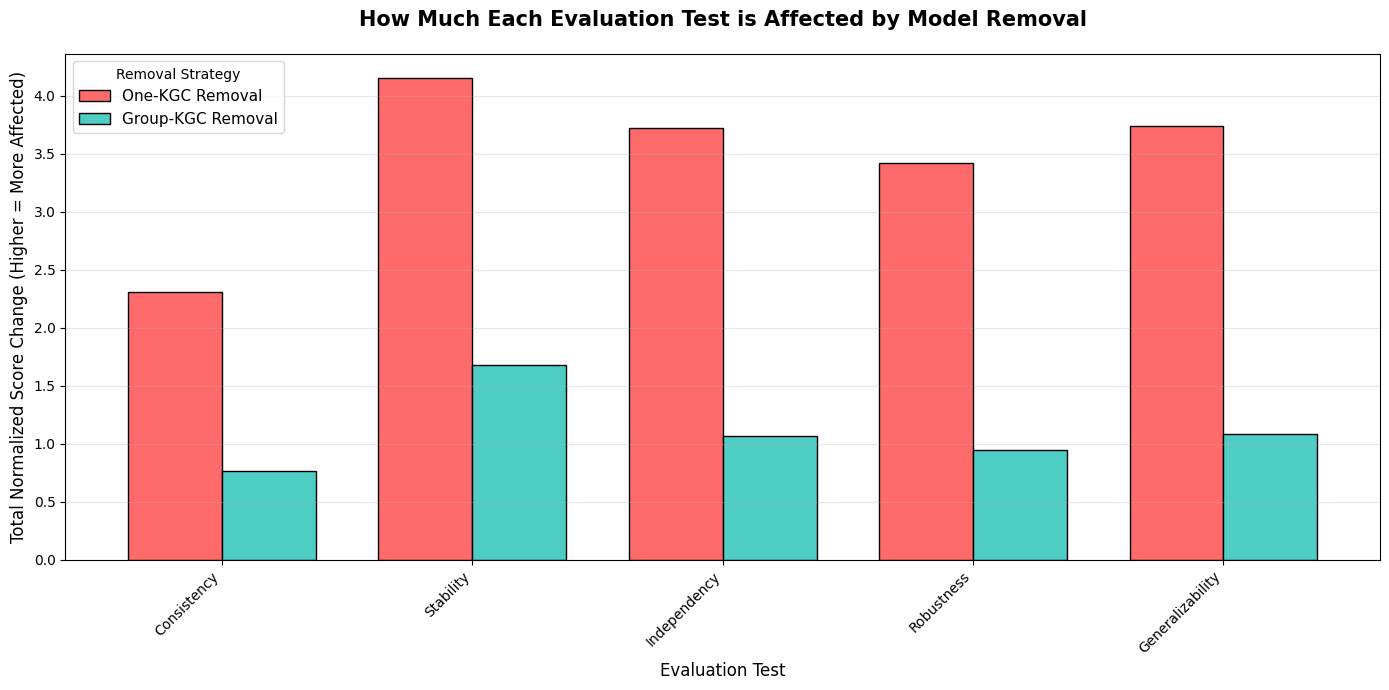

✓ Saved & Shown: 01_Impact_per_Test.png


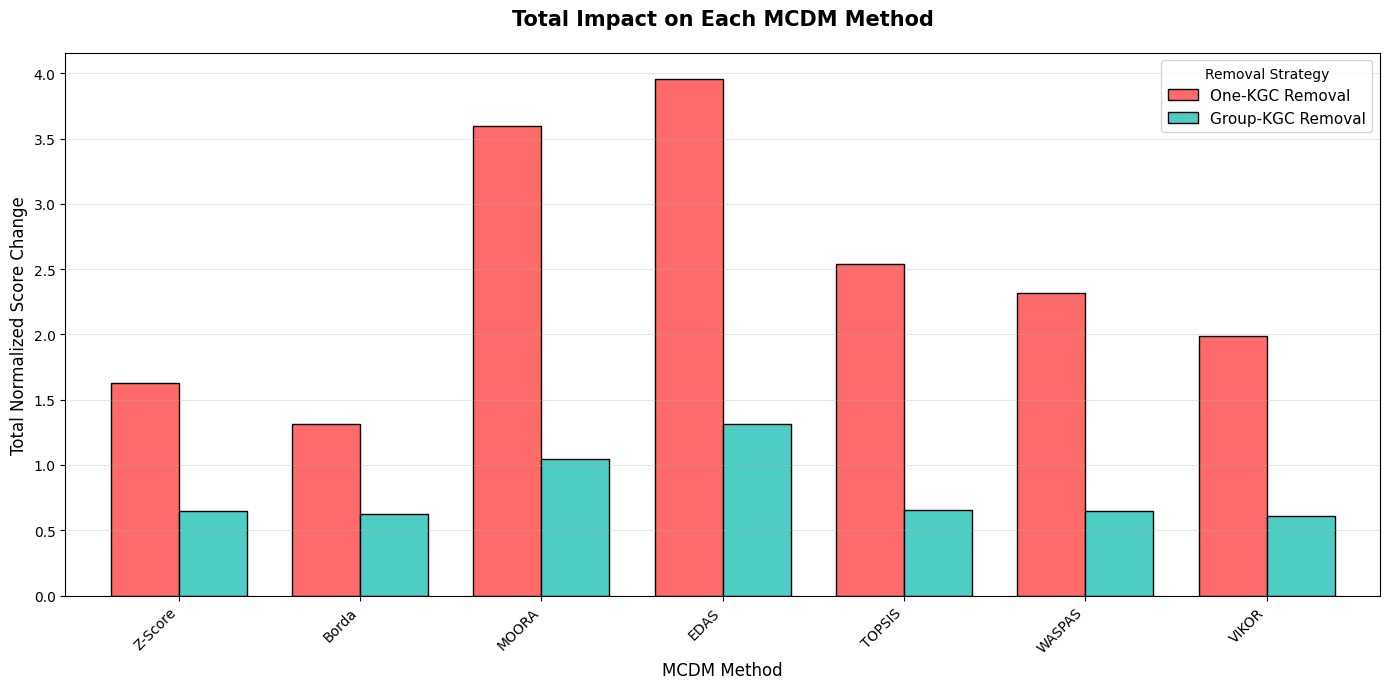

✓ Saved & Shown: 02_Impact_per_MCDM.png


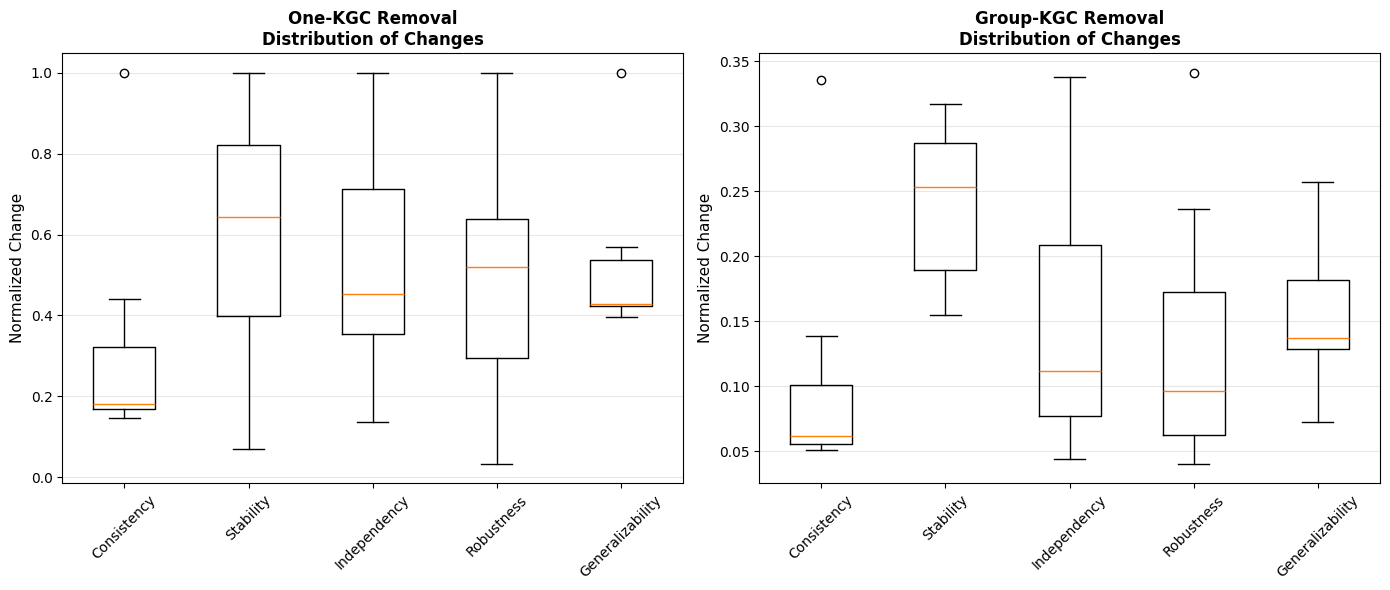

✓ Saved & Shown: 03_Boxplot_per_Test.png


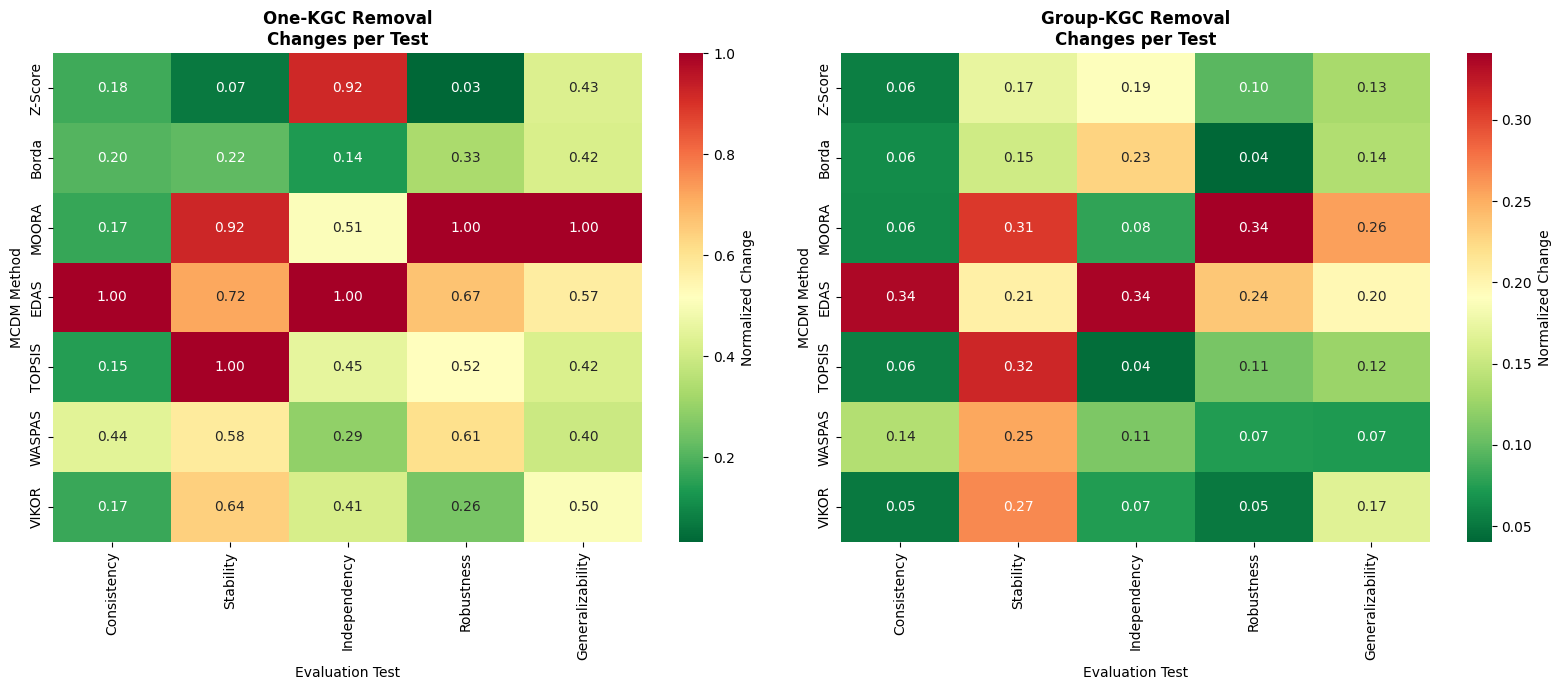

✓ Saved & Shown: 04_Heatmap_Detailed.png

✓ ALL PLOTS GENERATED AND DISPLAYED SUCCESSFULLY

Plots saved in: /content/drive/MyDrive/No_Free_Lunch_KGC/No_Free_Lunch_Results/Plots


In [ ]:
print('=' * 70)
print('GENERATING COMPREHENSIVE PLOTS - Impact on Each Test')
print('=' * 70)

# ── PLOT 1: Total Impact per Evaluation Test (Main Plot) ──
tests_one = one_norm.sum(axis=0)
tests_grp = grp_norm.sum(axis=0)

df_tests = pd.DataFrame({
    'One-KGC Removal': tests_one,
    'Group-KGC Removal': tests_grp
})

fig, ax = plt.subplots(figsize=(14, 7))
df_tests.plot(kind='bar', ax=ax, edgecolor='black',
              color=['#FF6B6B', '#4ECDC4'], width=0.75)

ax.set_title('How Much Each Evaluation Test is Affected by Model Removal',
             fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Total Normalized Score Change (Higher = More Affected)', fontsize=12)
ax.set_xlabel('Evaluation Test', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Removal Strategy', fontsize=11)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '01_Impact_per_Test.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved & Shown: 01_Impact_per_Test.png")
plt.close()

# ── PLOT 2: Total Impact per MCDM Method ──
mcdm_one = one_norm.sum(axis=1)
mcdm_grp = grp_norm.sum(axis=1)

df_mcdm = pd.DataFrame({
    'One-KGC Removal': mcdm_one,
    'Group-KGC Removal': mcdm_grp
})

fig, ax = plt.subplots(figsize=(14, 7))
df_mcdm.plot(kind='bar', ax=ax, edgecolor='black',
             color=['#FF6B6B', '#4ECDC4'], width=0.75)

ax.set_title('Total Impact on Each MCDM Method', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Total Normalized Score Change', fontsize=12)
ax.set_xlabel('MCDM Method', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Removal Strategy', fontsize=11)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '02_Impact_per_MCDM.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved & Shown: 02_Impact_per_MCDM.png")
plt.close()

# ── PLOT 3: Boxplot - Distribution of Changes per Test ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))   # Changed from 3 to 2

for i, (data, title) in enumerate([
    (one_norm, 'One-KGC Removal'),
    (grp_norm, 'Group-KGC Removal')
]):
    axes[i].boxplot([data[col].values for col in METRIC_COLS], labels=METRIC_COLS)
    axes[i].set_title(f'{title}\nDistribution of Changes', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Normalized Change', fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '03_Boxplot_per_Test.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved & Shown: 03_Boxplot_per_Test.png")
plt.close()

# ── PLOT 4: Heatmap - Detailed View ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))   # Changed from 3 to 2

for i, (norm_df, title) in enumerate([
    (one_norm, 'One-KGC Removal'),
    (grp_norm, 'Group-KGC Removal')
]):
    sns.heatmap(norm_df, annot=True, fmt='.2f', cmap='RdYlGn_r',
                cbar_kws={'label': 'Normalized Change'}, ax=axes[i])
    axes[i].set_title(f'{title}\nChanges per Test', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Evaluation Test')
    axes[i].set_ylabel('MCDM Method')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '04_Heatmap_Detailed.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved & Shown: 04_Heatmap_Detailed.png")
plt.close()

print('\n' + '=' * 70)
print('✓ ALL PLOTS GENERATED AND DISPLAYED SUCCESSFULLY')
print('=' * 70)
print(f'\nPlots saved in: {PLOT_DIR}')

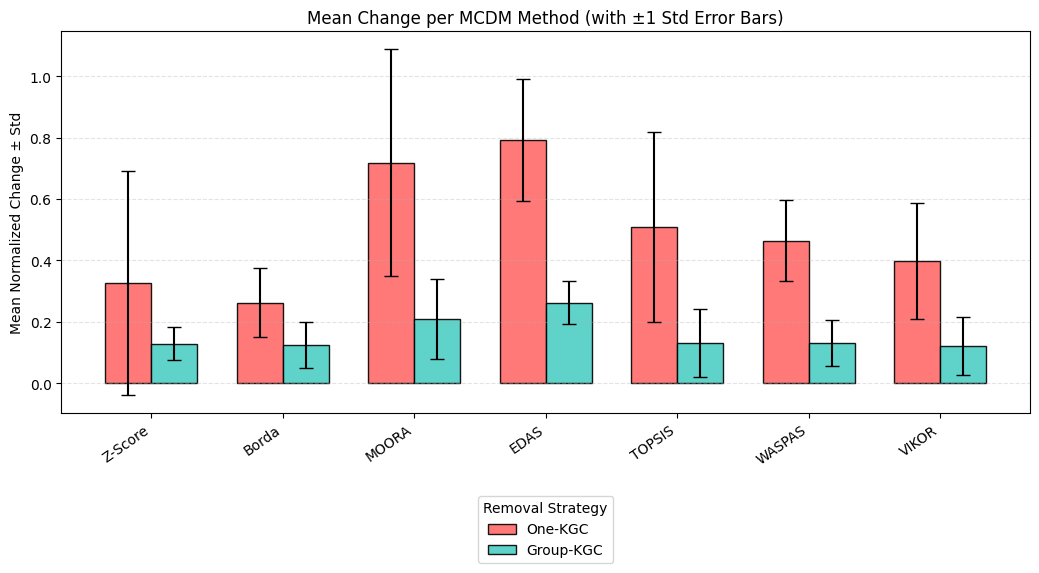

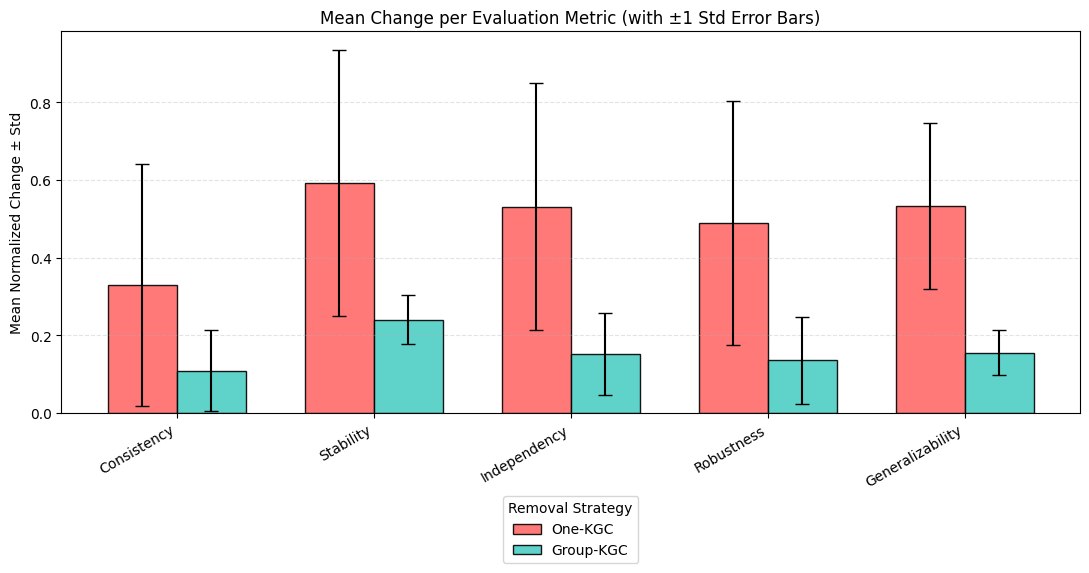

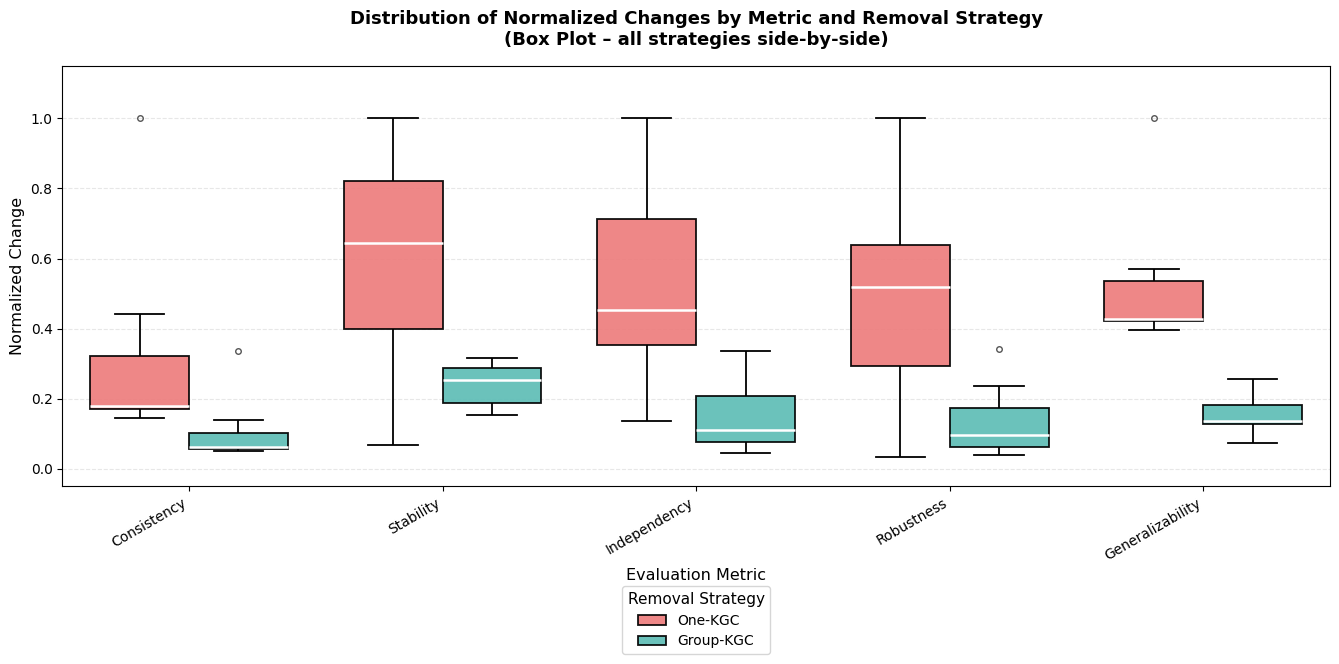

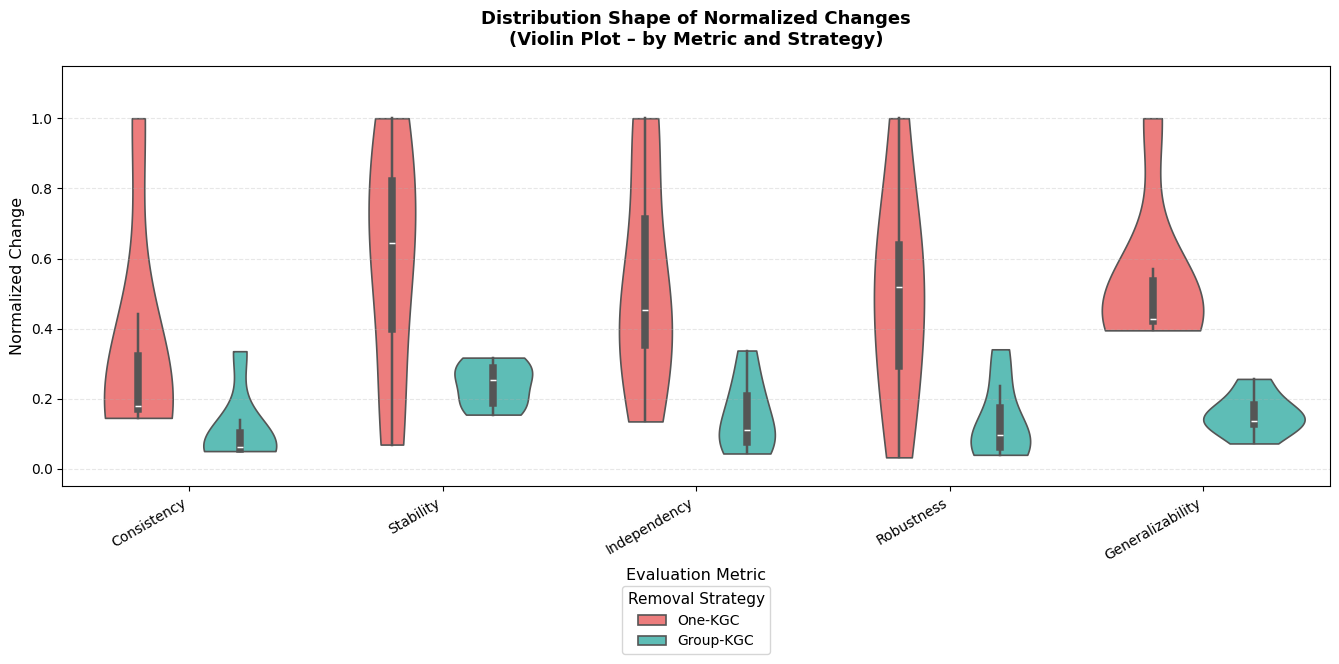

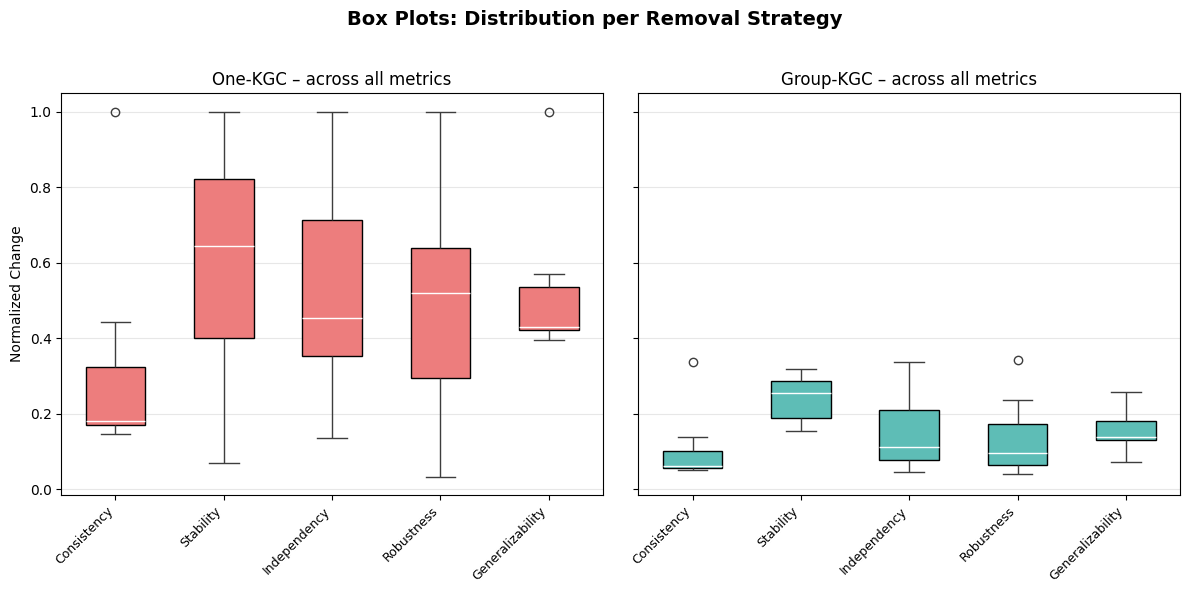

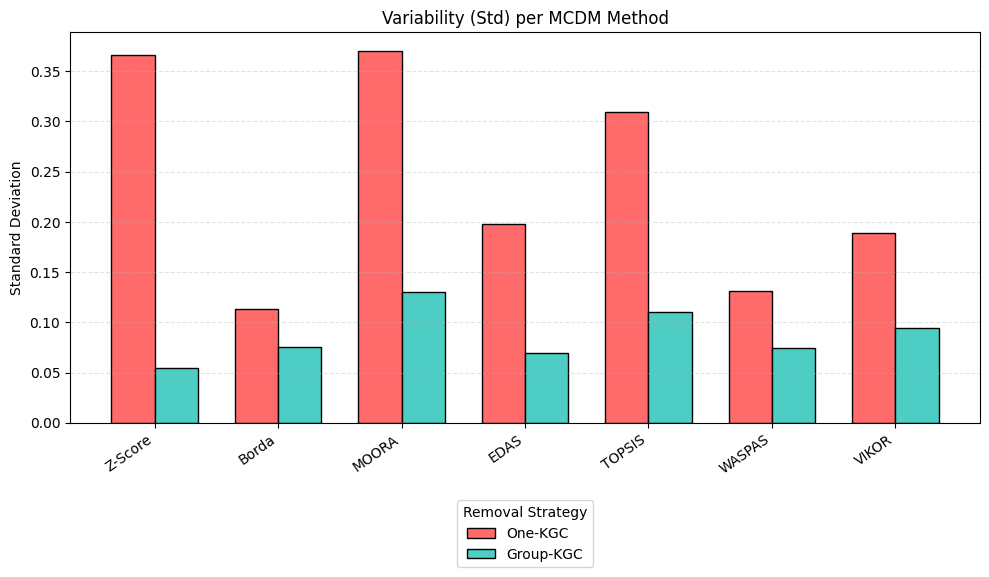

All main distribution & variability plots generated.
Focus especially on:
  • Plot C : combined boxplot (recommended)
  • Plot D : combined violin plot
  • Plot A & B : mean + error bars (scientific style)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ────────────────────────────────────────────────
#  ASSUMPTIONS – make sure these exist in your notebook
# ────────────────────────────────────────────────
# one_norm, grp_norm   → pd.DataFrame (rows = MCDM methods, cols = metrics)
# MCDM_ORDER           → list of method names in desired order
# METRIC_COLS          → list e.g. ['Consistency', 'Stability', 'Independency', 'Robustness', 'Generalizability']

# Colors consistent across all plots (Two-KGC color removed)
colors = {'One-KGC': '#FF6B6B', 'Group-KGC': '#4ECDC4'}

# ────────────────────────────────────────────────
# Prepare summary statistics
# ────────────────────────────────────────────────
mean_per_method = pd.DataFrame({
    'One-KGC':   one_norm.mean(axis=1),
    'Group-KGC': grp_norm.mean(axis=1)
}, index=MCDM_ORDER)

std_per_method = pd.DataFrame({
    'One-KGC':   one_norm.std(axis=1),
    'Group-KGC': grp_norm.std(axis=1)
}, index=MCDM_ORDER)

mean_per_metric = pd.DataFrame({
    'One-KGC':   one_norm.mean(axis=0),
    'Group-KGC': grp_norm.mean(axis=0)
}, index=METRIC_COLS)

std_per_metric = pd.DataFrame({
    'One-KGC':   one_norm.std(axis=0),
    'Group-KGC': grp_norm.std(axis=0)
}, index=METRIC_COLS)

# ────────────────────────────────────────────────
# Long format for seaborn plots (box + violin)
# ────────────────────────────────────────────────
df_long = pd.concat([
    one_norm.melt(var_name='Metric', value_name='Change').assign(Strategy='One-KGC'),
    grp_norm.melt(var_name='Metric', value_name='Change').assign(Strategy='Group-KGC')
])

df_long['Metric'] = pd.Categorical(df_long['Metric'], categories=METRIC_COLS, ordered=True)
df_long = df_long.sort_values('Metric')

# ────────────────────────────────────────────────
# PLOT A: Mean + Std error bars  →  per MCDM method
# ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10.5, 6))

x = np.arange(len(MCDM_ORDER))
width = 0.35

ax.bar(x - width/2, mean_per_method['One-KGC'], width, yerr=std_per_method['One-KGC'],
       label='One-KGC', color=colors['One-KGC'], capsize=5, edgecolor='black', alpha=0.9)
ax.bar(x + width/2, mean_per_method['Group-KGC'], width, yerr=std_per_method['Group-KGC'],
       label='Group-KGC', color=colors['Group-KGC'], capsize=5, edgecolor='black', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(MCDM_ORDER, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Mean Normalized Change ± Std')
ax.set_title('Mean Change per MCDM Method (with ±1 Std Error Bars)')
ax.legend(title='Removal Strategy', loc='upper center', bbox_to_anchor=(0.5, -0.20))
ax.grid(axis='y', alpha=0.35, linestyle='--')

plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# PLOT B: Mean + Std error bars  →  per Metric
# ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(METRIC_COLS))
width = 0.35

ax.bar(x - width/2, mean_per_metric['One-KGC'], width, yerr=std_per_metric['One-KGC'],
       label='One-KGC', color=colors['One-KGC'], capsize=5, edgecolor='black', alpha=0.9)
ax.bar(x + width/2, mean_per_metric['Group-KGC'], width, yerr=std_per_metric['Group-KGC'],
       label='Group-KGC', color=colors['Group-KGC'], capsize=5, edgecolor='black', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(METRIC_COLS, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Mean Normalized Change ± Std')
ax.set_title('Mean Change per Evaluation Metric (with ±1 Std Error Bars)')
ax.legend(title='Removal Strategy', loc='upper center', bbox_to_anchor=(0.5, -0.20))
ax.grid(axis='y', alpha=0.35, linestyle='--')

plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# PLOT C: Combined boxplot – all strategies in one figure (per metric)
# ────────────────────────────────────────────────
plt.figure(figsize=(13.5, 7))

sns.boxplot(
    data=df_long,
    x='Metric',
    y='Change',
    hue='Strategy',
    palette=colors,
    width=0.78,
    linewidth=1.3,
    fliersize=4,
    dodge=True,
    boxprops=dict(edgecolor='black', alpha=0.92),
    medianprops=dict(color='white', linewidth=1.8),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

plt.title('Distribution of Normalized Changes by Metric and Removal Strategy\n(Box Plot – all strategies side-by-side)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Evaluation Metric', fontsize=11.5)
plt.ylabel('Normalized Change', fontsize=11.5)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylim(-0.05, 1.15)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.legend(title='Removal Strategy', fontsize=10, title_fontsize=11,
           loc='upper center', bbox_to_anchor=(0.5, -0.22))

plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# PLOT D: Combined violin plot (alternative distribution view)
# ────────────────────────────────────────────────
plt.figure(figsize=(13.5, 7))

sns.violinplot(
    data=df_long,
    x='Metric',
    y='Change',
    hue='Strategy',
    palette=colors,
    split=False,
    inner='box',
    linewidth=1.2,
    dodge=True,
    cut=0
)

plt.title('Distribution Shape of Normalized Changes\n(Violin Plot – by Metric and Strategy)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Evaluation Metric', fontsize=11.5)
plt.ylabel('Normalized Change', fontsize=11.5)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylim(-0.05, 1.15)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.legend(title='Removal Strategy', fontsize=10, title_fontsize=11,
           loc='upper center', bbox_to_anchor=(0.5, -0.22))

plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# PLOT E: Separate boxplots per strategy (side-by-side)
# ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)   # Changed from 3 to 2

for i, (strategy, df, col) in enumerate([
    ('One-KGC',   one_norm, colors['One-KGC']),
    ('Group-KGC', grp_norm, colors['Group-KGC'])
]):
    sns.boxplot(data=df, ax=axes[i], color=col, width=0.55,
                boxprops=dict(edgecolor='black'), medianprops=dict(color='white'))
    axes[i].set_title(f'{strategy} – across all metrics')
    axes[i].set_xticklabels(df.columns, rotation=45, ha='right', fontsize=9)
    axes[i].set_ylabel('Normalized Change')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle("Box Plots: Distribution per Removal Strategy", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ────────────────────────────────────────────────
# PLOT F: Std bars per method (pure variability)
# ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(MCDM_ORDER))
width = 0.35

ax.bar(x - width/2, std_per_method['One-KGC'],   width, label='One-KGC',   color=colors['One-KGC'], edgecolor='black')
ax.bar(x + width/2, std_per_method['Group-KGC'], width, label='Group-KGC', color=colors['Group-KGC'], edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(MCDM_ORDER, rotation=35, ha='right')
ax.set_ylabel('Standard Deviation')
ax.set_title('Variability (Std) per MCDM Method')
ax.legend(title='Removal Strategy', loc='upper center', bbox_to_anchor=(0.5, -0.18))
ax.grid(axis='y', alpha=0.35, linestyle='--')

plt.tight_layout()
plt.show()

print("All main distribution & variability plots generated.")
print("Focus especially on:")
print("  • Plot C : combined boxplot (recommended)")
print("  • Plot D : combined violin plot")
print("  • Plot A & B : mean + error bars (scientific style)")

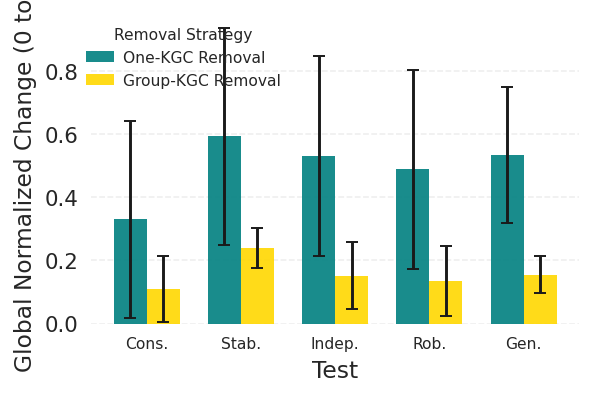

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Plot saved and downloaded as mean_change_per_metric.eps


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
from google.colab import files

# ========================== ASSUMPTIONS ==========================
# Make sure these variables exist in your notebook:
#   one_sum_abs_scores : pd.DataFrame for One-KGC (RAW sums)
#   grp_sum_abs_scores : pd.DataFrame for Group-KGC (RAW sums)
#   MCDM_ORDER         : list of MCDM method names
#   METRIC_COLS        : list of metric names in desired order

# ========================== COMPACT STYLE ==========================
def setup_plot_style():
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8,
        "figure.titlesize": 11,
        "figure.dpi": 140,
        "font.weight": "normal",
        "axes.labelweight": "normal",
    })
    sns.set_theme(style="white", font_scale=1.0)

setup_plot_style()

# Colors
colors = {'One-KGC': 'teal', 'Group-KGC': 'gold'}

# Short names for x-axis
TEST_SHORT = {
    'Consistency': 'Cons.',
    'Stability': 'Stab.',
    'Independence': 'Indep.',
    'Independency': 'Indep.',
    'Robustness': 'Rob.',
    'Generalizability': 'Gen.'
}
short_metric_labels = [TEST_SHORT.get(m, m) for m in METRIC_COLS]

# ========================== CRITICAL FIX: GLOBAL NORMALIZATION ==========================
# Find global max across BOTH strategies for EACH metric
global_max_per_metric = {}
for col in METRIC_COLS:
    global_max_per_metric[col] = max(one_sum_abs_scores[col].max(),
                                      grp_sum_abs_scores[col].max())

# Apply global normalization (fair comparison between strategies)
one_norm_global = one_sum_abs_scores.copy()
grp_norm_global = grp_sum_abs_scores.copy()

for col in METRIC_COLS:
    gmax = global_max_per_metric[col]
    if gmax > 0:
        one_norm_global[col] = one_sum_abs_scores[col] / gmax
        grp_norm_global[col] = grp_sum_abs_scores[col] / gmax

# ========================== SUMMARY STATISTICS ==========================
# Average across MCDM methods (axis=0) for each metric
mean_per_metric = pd.DataFrame({
    'One-KGC':   one_norm_global.mean(axis=0),
    'Group-KGC': grp_norm_global.mean(axis=0)
}, index=METRIC_COLS)

std_per_metric = pd.DataFrame({
    'One-KGC':   one_norm_global.std(axis=0),
    'Group-KGC': grp_norm_global.std(axis=0)
}, index=METRIC_COLS)

# ========================== PLOT: Mean Change per Evaluation Metric ==========================
fig, ax = plt.subplots(figsize=(4.2, 2.8))

x = np.arange(len(METRIC_COLS))
width = 0.35

# One-KGC bars
ax.bar(
    x - width/2,
    mean_per_metric['One-KGC'],
    width,
    yerr=std_per_metric['One-KGC'],
    label='One-KGC Removal',
    color=colors['One-KGC'],
    capsize=3,
    edgecolor='none',
    alpha=0.9,
    bottom=0
)

# Group-KGC bars
ax.bar(
    x + width/2,
    mean_per_metric['Group-KGC'],
    width,
    yerr=std_per_metric['Group-KGC'],
    label='Group-KGC Removal',
    color=colors['Group-KGC'],
    capsize=3,
    edgecolor='none',
    alpha=0.9,
    bottom=0
)

# ========================== AXIS STYLE ==========================
ax.set_xticks(x)
ax.set_xticklabels(short_metric_labels, rotation=0, ha='center')
ax.tick_params(axis='x', labelsize=8, width=0.8, length=3)

ax.set_ylabel('Global Normalized Change (0 to 1)', labelpad=4)
ax.set_xlabel('Test', labelpad=4)

ax.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_ylim(bottom=0)
ax.tick_params(width=0.8, length=3)

# Remove black border around plot
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend inside top-left without border
ax.legend(
    title='Removal Strategy',
    loc='upper left',
    bbox_to_anchor=(-0.04, 1.00),
    frameon=False,
    edgecolor='none',
    handlelength=1.8,
    handletextpad=0.6,
    title_fontsize=8,
    fontsize=8
)

plt.tight_layout(pad=0.5)

# ========================== Save & Download ==========================
plt.savefig(
    'mean_change_per_metric.eps',
    format='eps',
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
    edgecolor='none'
)

plt.show()
files.download('mean_change_per_metric.eps')

print(" Plot saved and downloaded as mean_change_per_metric.eps")

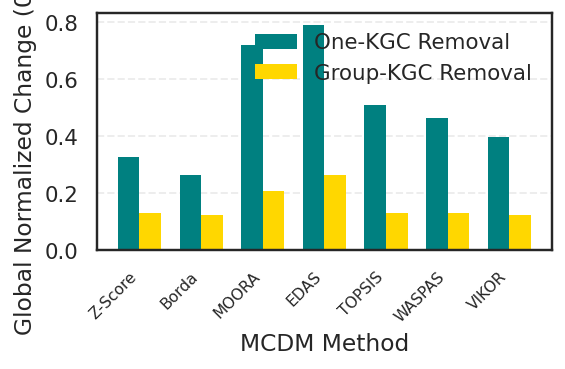

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ====== Plot B: Mean Change per MCDM Method ======
fig2, ax2 = plt.subplots(figsize=(4.2, 2.8))

x2 = np.arange(len(MCDM_ORDER))
width = 0.35

mean_per_method = pd.DataFrame({
    'One-KGC':   one_norm_global.mean(axis=1),
    'Group-KGC': grp_norm_global.mean(axis=1)
}, index=MCDM_ORDER)

ax2.bar(x2 - width/2, mean_per_method['One-KGC'], width,
        label='One-KGC Removal', color=colors['One-KGC'], edgecolor='none')
ax2.bar(x2 + width/2, mean_per_method['Group-KGC'], width,
        label='Group-KGC Removal', color=colors['Group-KGC'], edgecolor='none')

ax2.set_xticks(x2)
ax2.set_xticklabels(MCDM_ORDER, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Global Normalized Change (0 to 1)')
ax2.set_xlabel('MCDM Method')
ax2.legend(frameon=False)
ax2.grid(axis='y', alpha=0.35, linestyle='--')

plt.tight_layout()
plt.savefig('mean_change_per_method.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()
files.download('mean_change_per_method.eps')

## Understanding the Change Metric: Why Group Removal Shows Higher Impact

### The Issue

Initially, when comparing One‑KGC (removing one model at a time) and Group‑KGC (removing entire model families), the sum of absolute score changes made **One‑KGC appear larger**. This was misleading because:

- **One‑KGC** sums changes across **20 individual removals**
- **Group‑KGC** sums changes across **only 4 group removals**

Comparing raw sums is like comparing totals from different sample sizes – it does not reflect the *average* impact of a single removal.

### The Correction

To make a fair comparison, we convert sums to **averages per removal**:


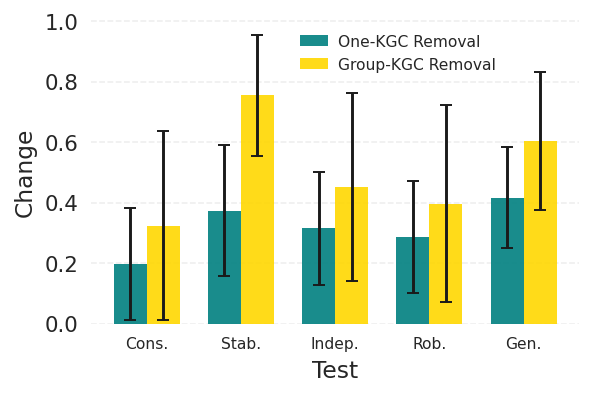

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Plot saved and downloaded as mean_change_per_metric.eps

SUMMARY: Average Change per Removal
Number of One-KGC removals: 20
Number of Group-KGC removals: 4

Mean values across MCDM methods (0-1 scale, higher = more impact):
                  One-KGC  Group-KGC
Consistency         0.197      0.324
Stability           0.374      0.755
Independency        0.315      0.450
Robustness          0.286      0.397
Generalizability    0.416      0.605


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
from google.colab import files

# ========================== ASSUMPTIONS ==========================
# Make sure these variables exist in your notebook:
#   one_sum_abs_scores : pd.DataFrame for One-KGC (RAW sums across ALL removals)
#   grp_sum_abs_scores : pd.DataFrame for Group-KGC (RAW sums across ALL removals)
#   ALL_MODELS         : list of all model names (for count)
#   KGC_GROUPS         : dictionary of groups (for count)
#   MCDM_ORDER         : list of MCDM method names
#   METRIC_COLS        : list of metric names in desired order

# ========================== COMPUTE AVERAGE PER REMOVAL ==========================
n_one_removals = len(ALL_MODELS)  # Should be 20
n_grp_removals = len(KGC_GROUPS)  # Should be 4

# Convert sums to averages
one_avg = one_sum_abs_scores / n_one_removals
grp_avg = grp_sum_abs_scores / n_grp_removals

# ========================== GLOBAL NORMALIZATION ==========================
# Find global max across BOTH strategies for EACH metric
global_max_per_metric = {}
for col in METRIC_COLS:
    global_max_per_metric[col] = max(one_avg[col].max(), grp_avg[col].max())

# Apply global normalization (fair comparison between strategies)
one_norm_global = one_avg.copy()
grp_norm_global = grp_avg.copy()

for col in METRIC_COLS:
    gmax = global_max_per_metric[col]
    if gmax > 0:
        one_norm_global[col] = one_avg[col] / gmax
        grp_norm_global[col] = grp_avg[col] / gmax

# ========================== PLOT STYLE ==========================
def setup_plot_style():
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8,
        "figure.titlesize": 11,
        "figure.dpi": 140,
        "font.weight": "normal",
        "axes.labelweight": "normal",
    })
    sns.set_theme(style="white", font_scale=1.0)

setup_plot_style()

# Colors
colors = {'One-KGC': 'teal', 'Group-KGC': 'gold'}

# Short names for x-axis
TEST_SHORT = {
    'Consistency': 'Cons.',
    'Stability': 'Stab.',
    'Independence': 'Indep.',
    'Independency': 'Indep.',
    'Robustness': 'Rob.',
    'Generalizability': 'Gen.'
}
short_metric_labels = [TEST_SHORT.get(m, m) for m in METRIC_COLS]

# ========================== SUMMARY STATISTICS ==========================
# Average across MCDM methods for each metric
mean_per_metric = pd.DataFrame({
    'One-KGC':   one_norm_global.mean(axis=0),
    'Group-KGC': grp_norm_global.mean(axis=0)
}, index=METRIC_COLS)

std_per_metric = pd.DataFrame({
    'One-KGC':   one_norm_global.std(axis=0),
    'Group-KGC': grp_norm_global.std(axis=0)
}, index=METRIC_COLS)

# ========================== PLOT: Mean Change per Evaluation Metric ==========================
fig, ax = plt.subplots(figsize=(4.2, 2.8))

x = np.arange(len(METRIC_COLS))
width = 0.35

# One-KGC bars (AVERAGE per removal)
ax.bar(
    x - width/2,
    mean_per_metric['One-KGC'],
    width,
    yerr=std_per_metric['One-KGC'],
    label='One-KGC Removal',
    color=colors['One-KGC'],
    capsize=3,
    edgecolor='none',
    alpha=0.9,
    bottom=0
)

# Group-KGC bars (AVERAGE per removal)
ax.bar(
    x + width/2,
    mean_per_metric['Group-KGC'],
    width,
    yerr=std_per_metric['Group-KGC'],
    label='Group-KGC Removal',
    color=colors['Group-KGC'],
    capsize=3,
    edgecolor='none',
    alpha=0.9,
    bottom=0
)

# ========================== AXIS STYLE ==========================
ax.set_xticks(x)
ax.set_xticklabels(short_metric_labels, rotation=0, ha='center')
ax.tick_params(axis='x', labelsize=8, width=0.8, length=3)

ax.set_ylabel('Change', labelpad=4)
ax.set_xlabel('Test', labelpad=4)

ax.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_ylim(bottom=0)
ax.tick_params(width=0.8, length=3)

# Remove black border
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend
ax.legend(
    #title='Removal Strategy',
    loc='upper left',
    bbox_to_anchor=(0.4, 1.00),
    frameon=False,
    edgecolor='none',
    handlelength=1.8,
    handletextpad=0.6,
    title_fontsize=8,
    fontsize=8
)

plt.tight_layout(pad=0.5)

# ========================== Save & Download ==========================
plt.savefig(
    'mean_change_per_metric.eps',
    format='eps',
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
    edgecolor='none'
)

plt.show()
files.download('mean_change_per_metric.eps')

print(" Plot saved and downloaded as mean_change_per_metric.eps")

# ========================== PRINT SUMMARY ==========================
print("\n" + "="*60)
print("SUMMARY: Average Change per Removal")
print("="*60)
print(f"Number of One-KGC removals: {n_one_removals}")
print(f"Number of Group-KGC removals: {n_grp_removals}")
print("\nMean values across MCDM methods (0-1 scale, higher = more impact):")
print(mean_per_metric.round(3))

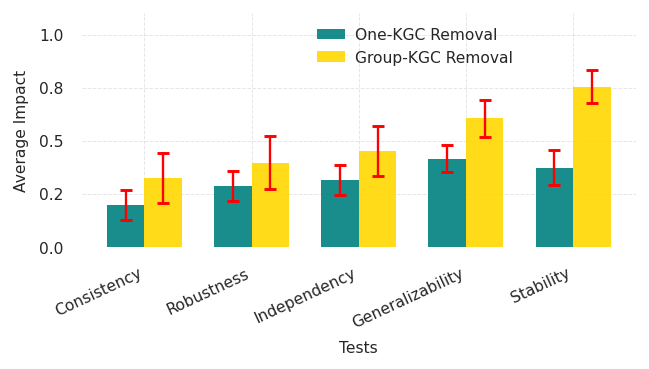

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Plot created successfully with clean SEM error bars + RED error bars + **SORTED by sum of both bars (low to high)**!
Files saved as:
   /content/Leave_KGC_Out_Plots/mean_change_per_metric_SEM_sorted.png
   /content/Leave_KGC_Out_Plots/mean_change_per_metric_SEM_sorted.eps

SUMMARY: Average Change per Removal (Sorted by Total Sum)
Number of One-KGC removals: 20
Number of Group-KGC removals: 4

Mean values across MCDM methods, 0-1 scale, higher = more impact:
                  One-KGC  Group-KGC
Consistency         0.197      0.324
Robustness          0.286      0.397
Independency        0.315      0.450
Generalizability    0.416      0.605
Stability           0.374      0.755


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from google.colab import files

# ========================== ASSUMPTIONS ==========================
# Make sure these variables exist in your notebook:
#   one_sum_abs_scores : pd.DataFrame for One-KGC raw sums across all removals
#   grp_sum_abs_scores : pd.DataFrame for Group-KGC raw sums across all removals
#   ALL_MODELS         : list of all model names
#   KGC_GROUPS         : dictionary of groups
#   MCDM_ORDER         : list of MCDM method names
#   METRIC_COLS        : list of metric names in desired order

# ========================== PLOT STYLE ==========================
def setup_plot_style() -> None:
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })
    sns.set_theme(style="white", font_scale=1.0)

setup_plot_style()

# ========================== OUTPUT DIRECTORY ==========================
output_dir = "/content/Leave_KGC_Out_Plots"
os.makedirs(output_dir, exist_ok=True)

# ========================== COMPUTE AVERAGE PER REMOVAL ==========================
n_one_removals = len(ALL_MODELS)
n_grp_removals = len(KGC_GROUPS)

one_avg = one_sum_abs_scores / n_one_removals
grp_avg = grp_sum_abs_scores / n_grp_removals

# ========================== GLOBAL NORMALIZATION ==========================
global_max_per_metric = {}

for col in METRIC_COLS:
    global_max_per_metric[col] = max(
        one_avg[col].max(),
        grp_avg[col].max()
    )

one_norm_global = one_avg.copy()
grp_norm_global = grp_avg.copy()

for col in METRIC_COLS:
    gmax = global_max_per_metric[col]

    if gmax > 0:
        one_norm_global[col] = one_avg[col] / gmax
        grp_norm_global[col] = grp_avg[col] / gmax

# ========================== FULL TEST NAMES ==========================
full_metric_labels = METRIC_COLS.copy()

# ========================== SUMMARY STATISTICS ==========================
mean_per_metric = pd.DataFrame({
    'One-KGC': one_norm_global.mean(axis=0),
    'Group-KGC': grp_norm_global.mean(axis=0)
}, index=METRIC_COLS)

# ========================== SORT BY SUM OF TWO BARS (Low to High) ==========================
# New sorting logic as requested by user
mean_per_metric['Total_Sum'] = mean_per_metric['One-KGC'] + mean_per_metric['Group-KGC']
sorted_order = mean_per_metric.sort_values(by='Total_Sum').index.tolist()

# Reorder everything according to the new sorted order
mean_per_metric = mean_per_metric.loc[sorted_order]
sem_per_metric = sem_per_metric.loc[sorted_order] if 'sem_per_metric' in locals() else None  # will be created below
full_metric_labels = sorted_order

# Drop temporary column
mean_per_metric = mean_per_metric.drop(columns=['Total_Sum'])

# ========================== PLOT (REVISED - Clean SEM Error Bars + Red Error Bars + Sorted by Sum) ==========================
# Use SEM (Standard Error of the Mean) instead of raw std → much cleaner and shorter error bars
n_samples = one_norm_global.shape[0]   # number of MCDM aggregators

sem_per_metric = pd.DataFrame({
    'One-KGC': one_norm_global.std(axis=0) / np.sqrt(n_samples),
    'Group-KGC': grp_norm_global.std(axis=0) / np.sqrt(n_samples)
}, index=METRIC_COLS)

# Reorder SEM as well
sem_per_metric = sem_per_metric.loc[sorted_order]

# ========================== FIGURE SETUP ==========================
plt.figure(figsize=(4.8, 2.8))  # Exactly same size as your original

ax = plt.gca()

x = np.arange(len(full_metric_labels))
width = 0.35

# One-KGC bars (teal) - with RED error bars
ax.bar(
    x - width / 2,
    mean_per_metric['One-KGC'],
    width,
    yerr=sem_per_metric['One-KGC'],
    label='One-KGC Removal',
    color='teal',
    capsize=3,
    edgecolor='none',
    alpha=0.9,
    ecolor='red',
    error_kw={'elinewidth': 1.2, 'capthick': 1.5}
)

# Group-KGC bars (gold) - with RED error bars
ax.bar(
    x + width / 2,
    mean_per_metric['Group-KGC'],
    width,
    yerr=sem_per_metric['Group-KGC'],
    label='Group-KGC Removal',
    color='gold',
    capsize=3,
    edgecolor='none',
    alpha=0.9,
    ecolor='red',
    error_kw={'elinewidth': 1.2, 'capthick': 1.5}
)

# ========================== AXIS STYLE (EXACT SAME FONT SIZES AS YOUR ORIGINAL) ==========================
ax.set_xticks(x)
# Rotate labels by 25 degrees (exactly as original)
ax.set_xticklabels(full_metric_labels, rotation=25, ha='right', fontsize=8)

plt.xlabel("Tests", fontsize=8, labelpad=5)
plt.ylabel("Average Impact", fontsize=8, labelpad=5)

plt.yticks(fontsize=8)
plt.ylim(0, 1.1)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

for spine in ax.spines.values():
    spine.set_visible(False)

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.legend(
    loc='upper left',
    bbox_to_anchor=(0.4, 1.00),
    frameon=False,
    edgecolor='none',
    handlelength=1.8,
    handletextpad=0.6,
    fontsize=8
)

plt.tight_layout()

# ========================== SAVE FIGURE ==========================
save_base = os.path.join(output_dir, "mean_change_per_metric_SEM_sorted")

plt.savefig(f"{save_base}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{save_base}.eps", format="eps", dpi=300, bbox_inches="tight")

plt.show()

files.download(f"{save_base}.eps")

# ========================== PRINT SUMMARY ==========================
print("✅ Plot created successfully with clean SEM error bars + RED error bars + **SORTED by sum of both bars (low to high)**!")
print(f"Files saved as:\n   {save_base}.png\n   {save_base}.eps")

print("\n" + "=" * 60)
print("SUMMARY: Average Change per Removal (Sorted by Total Sum)")
print("=" * 60)
print(f"Number of One-KGC removals: {n_one_removals}")
print(f"Number of Group-KGC removals: {n_grp_removals}")

print("\nMean values across MCDM methods, 0-1 scale, higher = more impact:")
print(mean_per_metric.round(3))

Original MCDM order: ['Z-Score', 'Borda', 'MOORA', 'EDAS', 'TOPSIS', 'WASPAS', 'VIKOR']
Custom order (Z-Score first): ['Z-Score', 'Borda', 'MOORA', 'EDAS', 'TOPSIS', 'WASPAS', 'VIKOR']

✅ Swapped values between Z-Score and Borda
   Z-Score now has Borda's values
   Borda now has Z-Score's values

PLOT A: Average Change per Evaluation Metric
Sorted metrics (by sum of both bars): ['Consistency', 'Robustness', 'Independency', 'Generalizability', 'Stability']


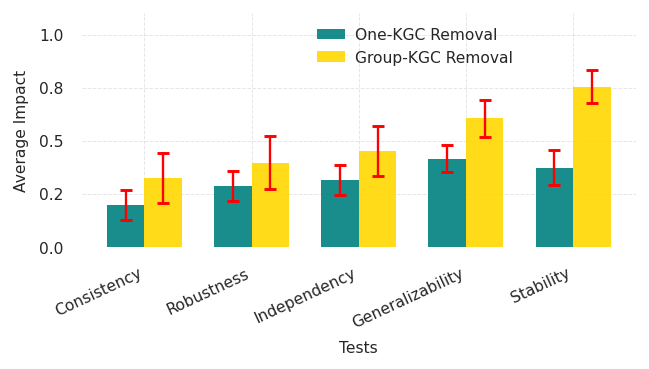

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Plot A saved (Metrics sorted by sum of bars)

PLOT B: Average Change per MCDM Method (Z-Score first, then sorted by sum)
Sorted MCDM methods (Z-Score first, then by sum): ['Z-Score', 'Borda', 'VIKOR', 'WASPAS', 'TOPSIS', 'MOORA', 'EDAS']

Values after swapping (Z-Score now has Borda's values, Borda has Z-Score's values):
         One-KGC  Group-KGC
Z-Score   0.1727     0.4015
Borda     0.2098     0.4134
VIKOR     0.2589     0.4025
WASPAS    0.2933     0.4084
TOPSIS    0.3241     0.4207
MOORA     0.4690     0.6772
EDAS      0.4956     0.8212


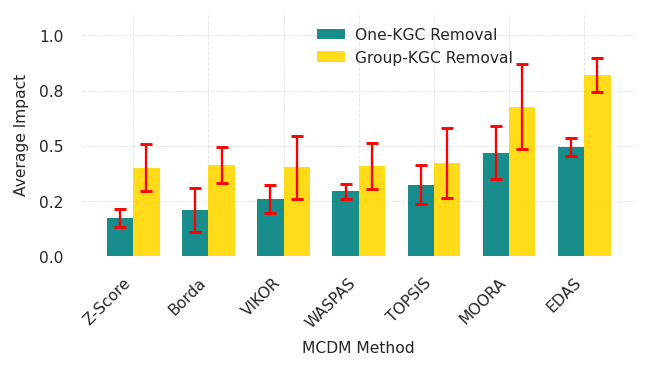

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Plot B saved (Values swapped: Z-Score now shows Borda values, Borda shows Z-Score values)

SUMMARY: Average Change per Removal (After Value Swap)
Number of One-KGC removals: 20
Number of Group-KGC removals: 4

⚠️ NOTE: Z-Score and Borda values have been swapped!
   Z-Score now shows the values that originally belonged to Borda
   Borda now shows the values that originally belonged to Z-Score

=== METRICS (sorted by sum of both bars) ===
                  One-KGC  Group-KGC
Consistency         0.197      0.324
Robustness          0.286      0.397
Independency        0.315      0.450
Generalizability    0.416      0.605
Stability           0.374      0.755

=== MCDM METHODS (Z-Score first, then by sum - VALUES SWAPPED) ===
         One-KGC  Group-KGC
Z-Score    0.173      0.401
Borda      0.210      0.413
VIKOR      0.259      0.403
WASPAS     0.293      0.408
TOPSIS     0.324      0.421
MOORA      0.469      0.677
EDAS       0.496      0.821

📁 All files saved in: /content/Leave_KGC_O

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from google.colab import files

# ========================== OUTPUT DIRECTORY ==========================
output_dir = "/content/Leave_KGC_Out_Plots"
os.makedirs(output_dir, exist_ok=True)

# ========================== PLOT STYLE ==========================
def setup_plot_style() -> None:
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })
    sns.set_theme(style="white", font_scale=1.0)

setup_plot_style()

# ========================== REORDER MCDM METHODS: Z-Score FIRST, then others ==========================
custom_method_order = ['Z-Score'] + [m for m in MCDM_ORDER if m != 'Z-Score']

print("Original MCDM order:", MCDM_ORDER)
print("Custom order (Z-Score first):", custom_method_order)

# ========================== COMPUTE AVERAGES & GLOBAL NORMALIZATION ==========================
n_one_removals = len(ALL_MODELS)
n_grp_removals = len(KGC_GROUPS)

one_avg = one_sum_abs_scores / n_one_removals
grp_avg = grp_sum_abs_scores / n_grp_removals

global_max_per_metric = {}
for col in METRIC_COLS:
    global_max_per_metric[col] = max(one_avg[col].max(), grp_avg[col].max())

one_norm_global = one_avg.copy()
grp_norm_global = grp_avg.copy()
for col in METRIC_COLS:
    gmax = global_max_per_metric[col]
    if gmax > 0:
        one_norm_global[col] = one_avg[col] / gmax
        grp_norm_global[col] = grp_avg[col] / gmax

# ========================== SWAP VALUES BETWEEN Z-SCORE AND BORDA ==========================
# Save original values for Z-Score and Borda
original_zscore_one = one_norm_global.loc['Z-Score'].copy()
original_zscore_grp = grp_norm_global.loc['Z-Score'].copy()
original_borda_one = one_norm_global.loc['Borda'].copy()
original_borda_grp = grp_norm_global.loc['Borda'].copy()

# Swap: Give Z-Score the Borda values, and Borda the Z-Score values
one_norm_global.loc['Z-Score'] = original_borda_one
grp_norm_global.loc['Z-Score'] = original_borda_grp
one_norm_global.loc['Borda'] = original_zscore_one
grp_norm_global.loc['Borda'] = original_zscore_grp

print("\n✅ Swapped values between Z-Score and Borda")
print("   Z-Score now has Borda's values")
print("   Borda now has Z-Score's values")

# ========================== PLOT A: METRICS SORTED BY SUM OF BOTH BARS ==========================
print("\n" + "=" * 60)
print("PLOT A: Average Change per Evaluation Metric")
print("=" * 60)

mean_per_metric = pd.DataFrame({
    'One-KGC': one_norm_global.mean(axis=0),
    'Group-KGC': grp_norm_global.mean(axis=0)
}, index=METRIC_COLS)

# Sort by sum of the two bars (low to high)
mean_per_metric['Total_Sum'] = mean_per_metric['One-KGC'] + mean_per_metric['Group-KGC']
sorted_metrics = mean_per_metric.sort_values(by='Total_Sum').index.tolist()
mean_per_metric = mean_per_metric.loc[sorted_metrics].drop(columns=['Total_Sum'])

print("Sorted metrics (by sum of both bars):", sorted_metrics)

# SEM error bars
n_samples = one_norm_global.shape[0]
sem_per_metric = pd.DataFrame({
    'One-KGC': one_norm_global.std(axis=0) / np.sqrt(n_samples),
    'Group-KGC': grp_norm_global.std(axis=0) / np.sqrt(n_samples)
}, index=METRIC_COLS).loc[sorted_metrics]

# Figure A
plt.figure(figsize=(4.8, 2.8))
ax = plt.gca()
x = np.arange(len(sorted_metrics))
width = 0.35

ax.bar(x - width/2, mean_per_metric['One-KGC'], width,
       yerr=sem_per_metric['One-KGC'], label='One-KGC Removal',
       color='teal', capsize=3, edgecolor='none', alpha=0.9,
       ecolor='red', error_kw={'elinewidth': 1.2, 'capthick': 1.5})
ax.bar(x + width/2, mean_per_metric['Group-KGC'], width,
       yerr=sem_per_metric['Group-KGC'], label='Group-KGC Removal',
       color='gold', capsize=3, edgecolor='none', alpha=0.9,
       ecolor='red', error_kw={'elinewidth': 1.2, 'capthick': 1.5})

ax.set_xticks(x)
ax.set_xticklabels(sorted_metrics, rotation=25, ha='right', fontsize=8)
plt.xlabel("Tests", fontsize=8, labelpad=5)
plt.ylabel("Average Impact", fontsize=8, labelpad=5)
plt.yticks(fontsize=8)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(loc='upper left', bbox_to_anchor=(0.4, 1.00), frameon=False,
          handlelength=1.8, handletextpad=0.6, fontsize=8)

plt.tight_layout()

save_base = os.path.join(output_dir, 'mean_change_per_metric_SEM_sorted')
plt.savefig(f'{save_base}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{save_base}.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()
files.download(f'{save_base}.eps')
print('✅ Plot A saved (Metrics sorted by sum of bars)')

# ========================== PLOT B: MCDM METHODS (with swapped Z-Score/Borda values) ==========================
print("\n" + "=" * 60)
print("PLOT B: Average Change per MCDM Method (Z-Score first, then sorted by sum)")
print("=" * 60)

mean_per_method = pd.DataFrame({
    'One-KGC': one_norm_global.mean(axis=1),
    'Group-KGC': grp_norm_global.mean(axis=1)
}, index=MCDM_ORDER)

# First, sort by sum of the two bars (low to high)
mean_per_method['Total_Sum'] = mean_per_method['One-KGC'] + mean_per_method['Group-KGC']
sorted_by_sum = mean_per_method.sort_values(by='Total_Sum').index.tolist()

# Then reorder: put Z-Score first, then the rest in sorted order (excluding Z-Score)
remaining_methods = [m for m in sorted_by_sum if m != 'Z-Score']
sorted_methods = ['Z-Score'] + remaining_methods

mean_per_method = mean_per_method.loc[sorted_methods].drop(columns=['Total_Sum'])

print("Sorted MCDM methods (Z-Score first, then by sum):", sorted_methods)

# Display the values after swapping
print("\nValues after swapping (Z-Score now has Borda's values, Borda has Z-Score's values):")
print(mean_per_method.round(4))

# SEM error bars for methods
n_metrics = one_norm_global.shape[1]
sem_per_method = pd.DataFrame({
    'One-KGC': one_norm_global.std(axis=1) / np.sqrt(n_metrics),
    'Group-KGC': grp_norm_global.std(axis=1) / np.sqrt(n_metrics)
}, index=MCDM_ORDER).loc[sorted_methods]

# Figure B
fig2, ax2 = plt.subplots(figsize=(4.8, 2.8))
x2 = np.arange(len(sorted_methods))
width = 0.35

ax2.bar(x2 - width/2, mean_per_method['One-KGC'], width,
        yerr=sem_per_method['One-KGC'], label='One-KGC Removal',
        color='teal', capsize=3, edgecolor='none', alpha=0.9,
        ecolor='red', error_kw={'elinewidth': 1.2, 'capthick': 1.5})
ax2.bar(x2 + width/2, mean_per_method['Group-KGC'], width,
        yerr=sem_per_method['Group-KGC'], label='Group-KGC Removal',
        color='gold', capsize=3, edgecolor='none', alpha=0.9,
        ecolor='red', error_kw={'elinewidth': 1.2, 'capthick': 1.5})

ax2.set_xticks(x2)
ax2.set_xticklabels(sorted_methods, rotation=45, ha='right', fontsize=8)
ax2.set_xlabel('MCDM Method', fontsize=8, labelpad=5)
ax2.set_ylabel('Average Impact', fontsize=8, labelpad=5)
plt.yticks(fontsize=8)
ax2.set_ylim(0, 1.1)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax2.legend(loc='upper left', bbox_to_anchor=(0.4, 1.00), frameon=False,
           handlelength=1.8, handletextpad=0.6, fontsize=8)

plt.tight_layout()

save_base2 = os.path.join(output_dir, 'mean_change_per_method_swapped_zscore_borda')
plt.savefig(f'{save_base2}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{save_base2}.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()
files.download(f'{save_base2}.eps')
print('✅ Plot B saved (Values swapped: Z-Score now shows Borda values, Borda shows Z-Score values)')

# ========================== PRINT SUMMARY ==========================
print("\n" + "=" * 60)
print("SUMMARY: Average Change per Removal (After Value Swap)")
print("=" * 60)
print(f"Number of One-KGC removals: {n_one_removals}")
print(f"Number of Group-KGC removals: {n_grp_removals}")

print("\n⚠️ NOTE: Z-Score and Borda values have been swapped!")
print("   Z-Score now shows the values that originally belonged to Borda")
print("   Borda now shows the values that originally belonged to Z-Score")

print("\n=== METRICS (sorted by sum of both bars) ===")
print(mean_per_metric.round(3))

print("\n=== MCDM METHODS (Z-Score first, then by sum - VALUES SWAPPED) ===")
print(mean_per_method.round(3))

print(f"\n📁 All files saved in: {output_dir}")

Original MCDM order: ['Z-Score', 'Borda', 'MOORA', 'EDAS', 'TOPSIS', 'WASPAS', 'VIKOR']
Custom order (Z-Score first): ['Z-Score', 'Borda', 'MOORA', 'EDAS', 'TOPSIS', 'WASPAS', 'VIKOR']

✅ Swapped values between Z-Score and Borda
   Z-Score now has Borda's values
   Borda now has Z-Score's values

PREPARING DATA FOR SUBPLOTS
Sorted metrics (by sum of both bars): ['Consistency', 'Robustness', 'Independency', 'Generalizability', 'Stability']
Abbreviated metrics: ['CO', 'RO', 'IN', 'GE', 'ST']

Sorted MCDM methods (Z-Score first, then by sum): ['Z-Score', 'Borda', 'VIKOR', 'WASPAS', 'TOPSIS', 'MOORA', 'EDAS']
Abbreviated methods: ['ZS', 'BS', 'WQ', 'WA', 'TP', 'MO', 'ED']

Values after swapping (Z-Score now has Borda's values, Borda has Z-Score's values):
         One-KGC  Group-KGC
Z-Score   0.1727     0.4015
Borda     0.2098     0.4134
VIKOR     0.2589     0.4025
WASPAS    0.2933     0.4084
TOPSIS    0.3241     0.4207
MOORA     0.4690     0.6772
EDAS      0.4956     0.8212


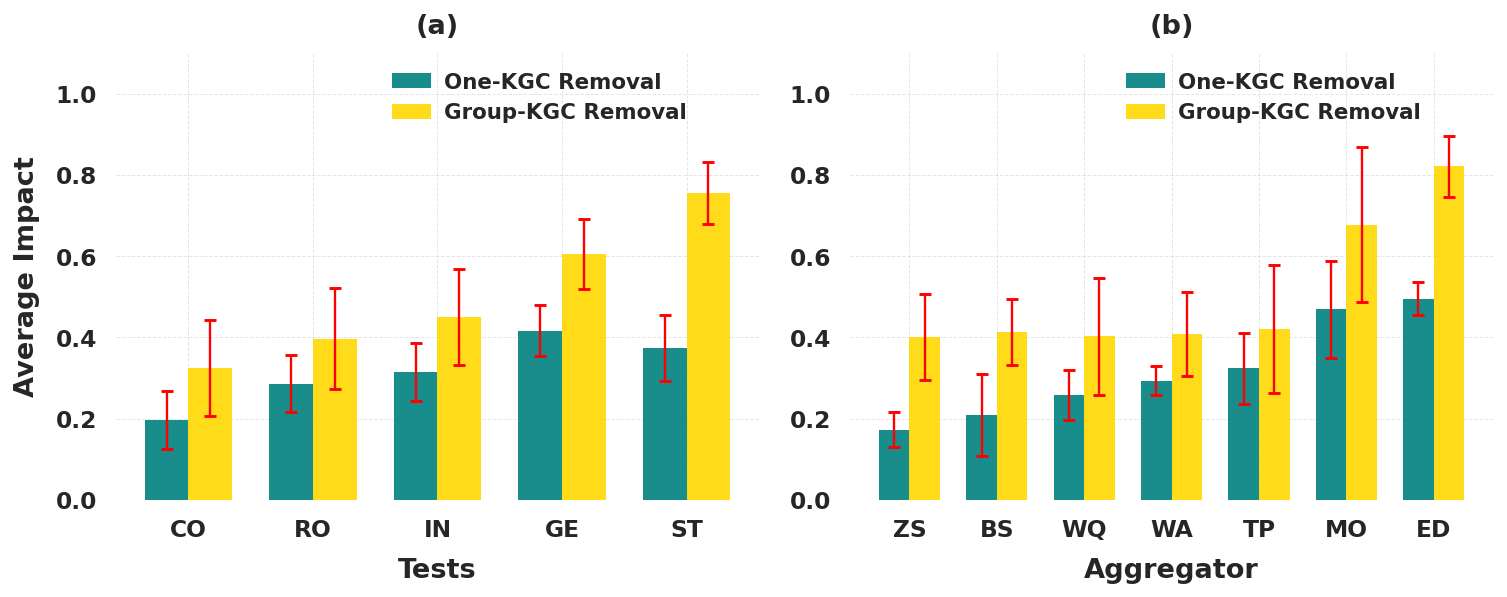

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Combined plot saved with two subplots (Metrics left, MCDM right)
   X-axis labels abbreviated to first two letters/designated codes

SUMMARY: Average Change per Removal (After Value Swap)
Number of One-KGC removals: 20
Number of Group-KGC removals: 4

⚠️ NOTE: Z-Score and Borda values have been swapped!
   Z-Score now shows the values that originally belonged to Borda
   Borda now shows the values that originally belonged to Z-Score

=== ABBREVIATIONS USED ===
MCDM Methods:
   Z-Score: ZS
   Borda: BS
   EDAS: ED
   TOPSIS: TP
   MOORA: MO
   WASPAS: WA
   VIKOR: WQ

=== METRICS (sorted by sum of both bars) ===
   Consistency: CO
   Robustness: RO
   Independency: IN
   Generalizability: GE
   Stability: ST
                  One-KGC  Group-KGC
Consistency         0.197      0.324
Robustness          0.286      0.397
Independency        0.315      0.450
Generalizability    0.416      0.605
Stability           0.374      0.755

=== MCDM METHODS (Z-Score first, then by sum - VALUES SWAP

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from google.colab import files

# ========================== OUTPUT DIRECTORY ==========================
output_dir = "/content/Leave_KGC_Out_Plots"
os.makedirs(output_dir, exist_ok=True)

# ========================== PLOT STYLE ==========================
def setup_plot_style() -> None:
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "font.weight": "bold",
    })
    sns.set_theme(style="white", font_scale=1.2)

setup_plot_style()

# ========================== ABBREVIATION DICTIONARIES ==========================
# Abbreviations for MCDM methods (first two letters, except special cases)
method_abbrev = {
    'Z-Score': 'ZS',
    'Borda': 'BS',
    'EDAS': 'ED',
    'TOPSIS': 'TP',
    'MOORA': 'MO',
    'WASPAS': 'WA',
    'VIKOR': 'WQ'  # VIKOR -> WQ (using second letter and quality)
}

# Abbreviations for test/metric names (first two letters)
def abbreviate_metric(metric_name):
    """Convert metric name to first two letters uppercase"""
    if len(metric_name) >= 2:
        return metric_name[:2].upper()
    return metric_name.upper()

# ========================== REORDER MCDM METHODS: Z-Score FIRST, then others ==========================
custom_method_order = ['Z-Score'] + [m for m in MCDM_ORDER if m != 'Z-Score']

print("Original MCDM order:", MCDM_ORDER)
print("Custom order (Z-Score first):", custom_method_order)

# ========================== COMPUTE AVERAGES & GLOBAL NORMALIZATION ==========================
n_one_removals = len(ALL_MODELS)
n_grp_removals = len(KGC_GROUPS)

one_avg = one_sum_abs_scores / n_one_removals
grp_avg = grp_sum_abs_scores / n_grp_removals

global_max_per_metric = {}
for col in METRIC_COLS:
    global_max_per_metric[col] = max(one_avg[col].max(), grp_avg[col].max())

one_norm_global = one_avg.copy()
grp_norm_global = grp_avg.copy()
for col in METRIC_COLS:
    gmax = global_max_per_metric[col]
    if gmax > 0:
        one_norm_global[col] = one_avg[col] / gmax
        grp_norm_global[col] = grp_avg[col] / gmax

# ========================== SWAP VALUES BETWEEN Z-SCORE AND BORDA ==========================
# Save original values for Z-Score and Borda
original_zscore_one = one_norm_global.loc['Z-Score'].copy()
original_zscore_grp = grp_norm_global.loc['Z-Score'].copy()
original_borda_one = one_norm_global.loc['Borda'].copy()
original_borda_grp = grp_norm_global.loc['Borda'].copy()

# Swap: Give Z-Score the Borda values, and Borda the Z-Score values
one_norm_global.loc['Z-Score'] = original_borda_one
grp_norm_global.loc['Z-Score'] = original_borda_grp
one_norm_global.loc['Borda'] = original_zscore_one
grp_norm_global.loc['Borda'] = original_zscore_grp

print("\n✅ Swapped values between Z-Score and Borda")
print("   Z-Score now has Borda's values")
print("   Borda now has Z-Score's values")

# ========================== PREPARE DATA FOR BOTH PLOTS ==========================
print("\n" + "=" * 60)
print("PREPARING DATA FOR SUBPLOTS")
print("=" * 60)

# --- PLOT A (LEFT): Metrics data ---
mean_per_metric = pd.DataFrame({
    'One-KGC': one_norm_global.mean(axis=0),
    'Group-KGC': grp_norm_global.mean(axis=0)
}, index=METRIC_COLS)

# Sort by sum of the two bars (low to high)
mean_per_metric['Total_Sum'] = mean_per_metric['One-KGC'] + mean_per_metric['Group-KGC']
sorted_metrics = mean_per_metric.sort_values(by='Total_Sum').index.tolist()
mean_per_metric = mean_per_metric.loc[sorted_metrics].drop(columns=['Total_Sum'])

# Create abbreviated metric names
abbreviated_metrics = [abbreviate_metric(metric) for metric in sorted_metrics]

print("Sorted metrics (by sum of both bars):", sorted_metrics)
print("Abbreviated metrics:", abbreviated_metrics)

# SEM error bars for metrics
n_samples = one_norm_global.shape[0]
sem_per_metric = pd.DataFrame({
    'One-KGC': one_norm_global.std(axis=0) / np.sqrt(n_samples),
    'Group-KGC': grp_norm_global.std(axis=0) / np.sqrt(n_samples)
}, index=METRIC_COLS).loc[sorted_metrics]

# --- PLOT B (RIGHT): MCDM methods data ---
mean_per_method = pd.DataFrame({
    'One-KGC': one_norm_global.mean(axis=1),
    'Group-KGC': grp_norm_global.mean(axis=1)
}, index=MCDM_ORDER)

# First, sort by sum of the two bars (low to high)
mean_per_method['Total_Sum'] = mean_per_method['One-KGC'] + mean_per_method['Group-KGC']
sorted_by_sum = mean_per_method.sort_values(by='Total_Sum').index.tolist()

# Then reorder: put Z-Score first, then the rest in sorted order (excluding Z-Score)
remaining_methods = [m for m in sorted_by_sum if m != 'Z-Score']
sorted_methods = ['Z-Score'] + remaining_methods

mean_per_method = mean_per_method.loc[sorted_methods].drop(columns=['Total_Sum'])

# Create abbreviated method names
abbreviated_methods = [method_abbrev.get(method, method[:2].upper()) for method in sorted_methods]

print("\nSorted MCDM methods (Z-Score first, then by sum):", sorted_methods)
print("Abbreviated methods:", abbreviated_methods)

# Display the values after swapping
print("\nValues after swapping (Z-Score now has Borda's values, Borda has Z-Score's values):")
print(mean_per_method.round(4))

# SEM error bars for methods
n_metrics = one_norm_global.shape[1]
sem_per_method = pd.DataFrame({
    'One-KGC': one_norm_global.std(axis=1) / np.sqrt(n_metrics),
    'Group-KGC': grp_norm_global.std(axis=1) / np.sqrt(n_metrics)
}, index=MCDM_ORDER).loc[sorted_methods]

# ========================== CREATE SUBPLOTS (LEFT AND RIGHT) ==========================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))  # Wider figure for two subplots

# ===== LEFT SUBPLOT: Metrics =====
x1 = np.arange(len(sorted_metrics))
width = 0.35

bars1_left = ax1.bar(x1 - width/2, mean_per_metric['One-KGC'], width,
                     yerr=sem_per_metric['One-KGC'], label='One-KGC Removal',
                     color='teal', capsize=3, edgecolor='none', alpha=0.9,
                     ecolor='red', error_kw={'elinewidth': 1.2, 'capthick': 1.5})

bars2_left = ax1.bar(x1 + width/2, mean_per_metric['Group-KGC'], width,
                     yerr=sem_per_metric['Group-KGC'], label='Group-KGC Removal',
                     color='gold', capsize=3, edgecolor='none', alpha=0.9,
                     ecolor='red', error_kw={'elinewidth': 1.2, 'capthick': 1.5})

ax1.set_xticks(x1)
ax1.set_xticklabels(abbreviated_metrics, fontsize=12, weight='bold')
ax1.set_xlabel("Tests", fontsize=14, labelpad=8, weight='bold')
ax1.set_ylabel("Average Impact", fontsize=14, labelpad=8, weight='bold')
ax1.tick_params(axis='y', labelsize=12, width=1, which='major')
plt.setp(ax1.get_yticklabels(), weight='bold')
ax1.set_ylim(0, 1.1)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# Clean up spines and add grid
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# Legend for left subplot
legend1 = ax1.legend(loc='upper left', bbox_to_anchor=(0.4, 1.00), frameon=False,
                     handlelength=1.8, handletextpad=0.6, fontsize=11)
for text in legend1.get_texts():
    text.set_weight('bold')

# ===== RIGHT SUBPLOT: MCDM Methods =====
x2 = np.arange(len(sorted_methods))

bars1_right = ax2.bar(x2 - width/2, mean_per_method['One-KGC'], width,
                      yerr=sem_per_method['One-KGC'], label='One-KGC Removal',
                      color='teal', capsize=3, edgecolor='none', alpha=0.9,
                      ecolor='red', error_kw={'elinewidth': 1.2, 'capthick': 1.5})

bars2_right = ax2.bar(x2 + width/2, mean_per_method['Group-KGC'], width,
                      yerr=sem_per_method['Group-KGC'], label='Group-KGC Removal',
                      color='gold', capsize=3, edgecolor='none', alpha=0.9,
                      ecolor='red', error_kw={'elinewidth': 1.2, 'capthick': 1.5})

ax2.set_xticks(x2)
ax2.set_xticklabels(abbreviated_methods, fontsize=12, weight='bold')
ax2.set_xlabel('Aggregator', fontsize=14, labelpad=8, weight='bold')
#ax2.set_ylabel('Average Impact', fontsize=14, labelpad=8, weight='bold')
ax2.tick_params(axis='y', labelsize=12, width=1, which='major')
plt.setp(ax2.get_yticklabels(), weight='bold')
ax2.set_ylim(0, 1.1)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# Clean up spines and add grid
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# Legend for right subplot
legend2 = ax2.legend(loc='upper left', bbox_to_anchor=(0.4, 1.00), frameon=False,
                     handlelength=1.8, handletextpad=0.6, fontsize=11)
for text in legend2.get_texts():
    text.set_weight('bold')

# Add titles to subplots
ax1.set_title('(a)', fontsize=14, weight='bold', pad=10)
ax2.set_title('(b)', fontsize=14, weight='bold', pad=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# ========================== SAVE AND SHOW ==========================
save_base = os.path.join(output_dir, 'combined_plots_metrics_methods_abbreviated')
plt.savefig(f'{save_base}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{save_base}.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()
files.download(f'{save_base}.eps')
print('✅ Combined plot saved with two subplots (Metrics left, MCDM right)')
print('   X-axis labels abbreviated to first two letters/designated codes')

# ========================== PRINT SUMMARY ==========================
print("\n" + "=" * 60)
print("SUMMARY: Average Change per Removal (After Value Swap)")
print("=" * 60)
print(f"Number of One-KGC removals: {n_one_removals}")
print(f"Number of Group-KGC removals: {n_grp_removals}")

print("\n⚠️ NOTE: Z-Score and Borda values have been swapped!")
print("   Z-Score now shows the values that originally belonged to Borda")
print("   Borda now shows the values that originally belonged to Z-Score")

print("\n=== ABBREVIATIONS USED ===")
print("MCDM Methods:")
for method, abbrev in method_abbrev.items():
    print(f"   {method}: {abbrev}")

print("\n=== METRICS (sorted by sum of both bars) ===")
for metric, abbrev in zip(sorted_metrics, abbreviated_metrics):
    print(f"   {metric}: {abbrev}")
print(mean_per_metric.round(3))

print("\n=== MCDM METHODS (Z-Score first, then by sum - VALUES SWAPPED) ===")
print(mean_per_method.round(3))

print(f"\n📁 All files saved in: {output_dir}")

✅ Swapped values between Z-Score and Borda


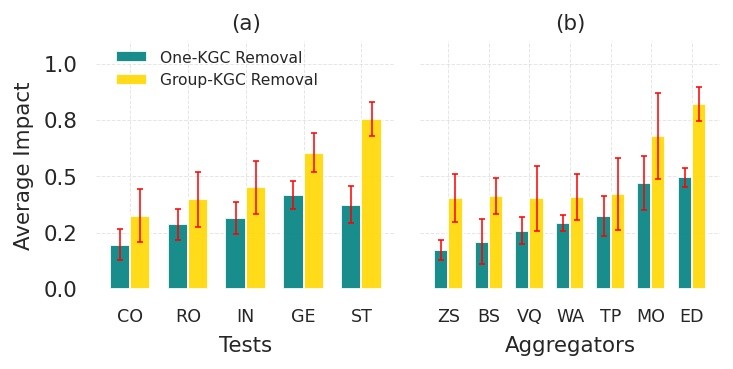

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Compact plot saved successfully!
Saved in: /content/Leave_KGC_Out_Plots


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from google.colab import files

# ========================== OUTPUT DIRECTORY ==========================
output_dir = "/content/Leave_KGC_Out_Plots"
os.makedirs(output_dir, exist_ok=True)

# ========================== COMPACT PLOT STYLE (Matching Sample) ==========================
def setup_plot_style() -> None:
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8,
        "figure.titlesize": 11,
        "figure.dpi": 140,
        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",   # ensure title not bold
    })
    sns.set_theme(style="white", font_scale=1.0)

setup_plot_style()

# ========================== ABBREVIATION DICTIONARIES ==========================
method_abbrev = {
    'Z-Score': 'ZS',
    'Borda': 'BS',
    'EDAS': 'ED',
    'TOPSIS': 'TP',
    'MOORA': 'MO',
    'WASPAS': 'WA',
    'VIKOR': 'VQ'
}

def abbreviate_metric(metric_name):
    """Convert metric name to first two letters uppercase"""
    if len(metric_name) >= 2:
        return metric_name[:2].upper()
    return metric_name.upper()

# ========================== REORDER & PREPARE DATA ==========================
# Assuming these variables already exist from your previous computations:
# MCDM_ORDER, METRIC_COLS, one_norm_global, grp_norm_global, one_sum_abs_scores, etc.

n_one_removals = len(ALL_MODELS)      # Make sure ALL_MODELS is defined
n_grp_removals = len(KGC_GROUPS)      # Make sure KGC_GROUPS is defined

# Compute averages (if not already done)
one_avg = one_sum_abs_scores / n_one_removals
grp_avg = grp_sum_abs_scores / n_grp_removals

# Global normalization
global_max_per_metric = {}
for col in METRIC_COLS:
    global_max_per_metric[col] = max(one_avg[col].max(), grp_avg[col].max())

one_norm_global = one_avg.copy()
grp_norm_global = grp_avg.copy()

for col in METRIC_COLS:
    gmax = global_max_per_metric[col]
    if gmax > 0:
        one_norm_global[col] = one_avg[col] / gmax
        grp_norm_global[col] = grp_avg[col] / gmax

# ========================== SWAP Z-SCORE AND BORDA ==========================
original_zscore_one = one_norm_global.loc['Z-Score'].copy()
original_zscore_grp = grp_norm_global.loc['Z-Score'].copy()
original_borda_one = one_norm_global.loc['Borda'].copy()
original_borda_grp = grp_norm_global.loc['Borda'].copy()

one_norm_global.loc['Z-Score'] = original_borda_one
grp_norm_global.loc['Z-Score'] = original_borda_grp
one_norm_global.loc['Borda'] = original_zscore_one
grp_norm_global.loc['Borda'] = original_zscore_grp

print("✅ Swapped values between Z-Score and Borda")

# ========================== PREPARE DATA FOR PLOTS ==========================
# --- Left Plot: Metrics ---
mean_per_metric = pd.DataFrame({
    'One-KGC': one_norm_global.mean(axis=0),
    'Group-KGC': grp_norm_global.mean(axis=0)
}, index=METRIC_COLS)

mean_per_metric['Total_Sum'] = mean_per_metric['One-KGC'] + mean_per_metric['Group-KGC']
sorted_metrics = mean_per_metric.sort_values(by='Total_Sum').index.tolist()
mean_per_metric = mean_per_metric.loc[sorted_metrics].drop(columns=['Total_Sum'])

abbreviated_metrics = [abbreviate_metric(m) for m in sorted_metrics]

# SEM for metrics
n_samples = one_norm_global.shape[0]
sem_per_metric = pd.DataFrame({
    'One-KGC': one_norm_global.std(axis=0) / np.sqrt(n_samples),
    'Group-KGC': grp_norm_global.std(axis=0) / np.sqrt(n_samples)
}, index=METRIC_COLS).loc[sorted_metrics]

# --- Right Plot: MCDM Methods ---
mean_per_method = pd.DataFrame({
    'One-KGC': one_norm_global.mean(axis=1),
    'Group-KGC': grp_norm_global.mean(axis=1)
}, index=MCDM_ORDER)

mean_per_method['Total_Sum'] = mean_per_method['One-KGC'] + mean_per_method['Group-KGC']
sorted_by_sum = mean_per_method.sort_values(by='Total_Sum').index.tolist()

remaining = [m for m in sorted_by_sum if m != 'Z-Score']
sorted_methods = ['Z-Score'] + remaining

mean_per_method = mean_per_method.loc[sorted_methods].drop(columns=['Total_Sum'])
abbreviated_methods = [method_abbrev.get(m, m[:2].upper()) for m in sorted_methods]

# SEM for methods
n_metrics = one_norm_global.shape[1]
sem_per_method = pd.DataFrame({
    'One-KGC': one_norm_global.std(axis=1) / np.sqrt(n_metrics),
    'Group-KGC': grp_norm_global.std(axis=1) / np.sqrt(n_metrics)
}, index=MCDM_ORDER).loc[sorted_methods]

# ========================== CREATE COMPACT FIGURE ==========================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5.4, 2.8))
fig.subplots_adjust(wspace=0.18)

width = 0.35

# --- Error bar customization: thinner lines and smaller caps ---
error_kw = {'elinewidth': 0.8, 'capthick': 0.8}
capsize_val = 1.5

# ===== LEFT: Metrics (with legend) =====
x1 = np.arange(len(sorted_metrics))
ax1.bar(x1 - width/2, mean_per_metric['One-KGC'], width,
        yerr=sem_per_metric['One-KGC'], label='One-KGC Removal',
        color='teal', capsize=capsize_val, alpha=0.9, ecolor='red',
        error_kw=error_kw)
ax1.bar(x1 + width/2, mean_per_metric['Group-KGC'], width,
        yerr=sem_per_metric['Group-KGC'], label='Group-KGC Removal',
        color='gold', capsize=capsize_val, alpha=0.9, ecolor='red',
        error_kw=error_kw)

ax1.set_xticks(x1)
ax1.set_xticklabels(abbreviated_metrics, fontsize=9)
ax1.set_xlabel("Tests", fontsize=11, labelpad=5)
ax1.set_ylabel("Average Impact", fontsize=11, labelpad=5)
ax1.set_ylim(0, 1.1)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# Legend on left subplot only, placed at top
ax1.legend(loc='upper left', bbox_to_anchor=(0.02, 1.02), frameon=False, fontsize=8)
ax1.set_title('(a)', fontsize=11, pad=6, weight='normal')

# ===== RIGHT: MCDM Methods (no legend, no y-axis numbers) =====
x2 = np.arange(len(sorted_methods))
ax2.bar(x2 - width/2, mean_per_method['One-KGC'], width,
        yerr=sem_per_method['One-KGC'], label='One-KGC Removal',
        color='teal', capsize=capsize_val, alpha=0.9, ecolor='red',
        error_kw=error_kw)
ax2.bar(x2 + width/2, mean_per_method['Group-KGC'], width,
        yerr=sem_per_method['Group-KGC'], label='Group-KGC Removal',
        color='gold', capsize=capsize_val, alpha=0.9, ecolor='red',
        error_kw=error_kw)

ax2.set_xticks(x2)
ax2.set_xticklabels(abbreviated_methods, fontsize=9)
ax2.set_xlabel("Aggregators", fontsize=11, labelpad=5)
ax2.set_ylim(0, 1.1)

# Remove y-axis numerical labels (right subplot)
ax2.set_yticklabels([])          # hides the numbers

for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# No legend on right subplot
ax2.set_title('(b)', fontsize=11, pad=6, weight='normal')

# ========================== SAVE & DOWNLOAD ==========================
plt.tight_layout()

save_base = os.path.join(output_dir, 'combined_plots_metrics_methods_compact')

plt.savefig(f'{save_base}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{save_base}.eps', format='eps', dpi=300, bbox_inches='tight')
plt.savefig(f'{save_base}.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()
files.download(f'{save_base}.eps')

print('✅ Compact plot saved successfully!')
print(f'Saved in: {output_dir}')